# 🎓 OULAD Student Performance Prediction
## End-to-End ML Pipeline — Full Feature Extraction Edition
> **Dataset**: Open University Learning Analytics Dataset (OULAD)  
> **Goal**: Predict student at-risk status with maximum accuracy & explainability  
> **Features**: ALL 7 tables fully exploited — VLE windows, registration timing, module-normalized engagement  
> **Models**: 9 classifiers + Optuna tuning + Ensemble + SHAP explainability


---
## ⚙️ SECTION 0 — Setup & Configuration

In [2]:
# ── Installs (run once) ──────────────────────────────────────
# !pip install category_encoders optuna shap imbalanced-learn xgboost lightgbm kaleido pyarrow joblib


In [3]:
import os, warnings, time
import numpy  as np
import pandas as pd
import matplotlib.pyplot    as plt
import matplotlib.ticker    as mtick
import seaborn              as sns
import plotly.express       as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Encoding
from sklearn.preprocessing   import OrdinalEncoder, LabelEncoder, StandardScaler, MinMaxScaler
import category_encoders     as ce

# Modeling
from sklearn.model_selection  import train_test_split, StratifiedKFold, cross_val_score, learning_curve
from sklearn.metrics          import (
    accuracy_score, f1_score, roc_auc_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,
    precision_recall_curve, average_precision_score
)
from sklearn.linear_model     import LogisticRegression
from sklearn.ensemble         import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm              import SVC
from sklearn.neighbors        import KNeighborsClassifier
from sklearn.neural_network   import MLPClassifier
from sklearn.tree             import DecisionTreeClassifier
from sklearn.calibration      import CalibratedClassifierCV
from sklearn.inspection       import permutation_importance

# Imbalance
from imblearn.over_sampling   import SMOTE, SMOTENC
from imblearn.combine         import SMOTETomek
from imblearn.pipeline        import Pipeline as ImbPipe
from imblearn.under_sampling  import TomekLinks

# Boosting
import xgboost  as xgb
import lightgbm as lgb

# Explainability
import shap

# Tuning
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Misc
import joblib

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.3f}'.format)

# ── Global style ─────────────────────────────────────────────
CLR = dict(
    Pass        = '#4CC9F0',
    Distinction = '#4361EE',
    Fail        = '#F72585',
    Withdrawn   = '#7209B7',
    palette     = ['#4361EE','#F72585','#4CC9F0','#7209B7','#3A0CA3','#F3722C','#06D6A0','#FFD166','#EF476F','#118AB2']
)

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.25,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 11,
})

SEED      = 42
DATA_PATH = './'   # ← CSV files location

print('✅  Libraries ready — OULAD Professional Pipeline')
print(f'   NumPy {np.__version__} | Pandas {pd.__version__} | XGBoost {xgb.__version__} | LightGBM {lgb.__version__}')


✅  Libraries ready — OULAD Professional Pipeline
   NumPy 2.2.6 | Pandas 2.3.3 | XGBoost 3.2.0 | LightGBM 4.6.0


c:\Users\Sigma\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## 📂 SECTION 1 — Data Loading & Profiling

In [4]:
FILES = {
    'student_info'        : 'studentInfo.csv',
    'student_vle'         : 'studentVle.csv',
    'student_assessment'  : 'studentAssessment.csv',
    'student_registration': 'studentRegistration.csv',
    'assessments'         : 'assessments.csv',
    'vle'                 : 'vle.csv',
    'courses'             : 'courses.csv',
}

T = {}
print('📂  Loading tables:\n')
for key, fname in FILES.items():
    path = os.path.join(DATA_PATH, fname)
    if os.path.exists(path):
        T[key] = pd.read_csv(path)
        r, c   = T[key].shape
        mem    = T[key].memory_usage(deep=True).sum() / 1e6
        print(f'  ✅  {fname:<35}  {r:>8,} rows × {c} cols   ({mem:.1f} MB)')
    else:
        print(f'  ⚠️   {fname} — NOT FOUND')

si    = T['student_info'].copy()
sv    = T['student_vle'].copy()
sa    = T['student_assessment'].copy()
reg   = T['student_registration'].copy()
asmts = T['assessments'].copy()
vle   = T['vle'].copy()

print(f'\n📋  studentInfo columns : {si.columns.tolist()}')
print(f'📋  Target classes      : {si["final_result"].unique()}')
print(f'📋  Total students      : {si["id_student"].nunique():,}')


📂  Loading tables:

  ✅  studentInfo.csv                        32,593 rows × 12 cols   (17.1 MB)
  ✅  studentVle.csv                       10,655,280 rows × 6 cols   (1470.4 MB)
  ✅  studentAssessment.csv                 173,912 rows × 5 cols   (7.0 MB)
  ✅  studentRegistration.csv                32,593 rows × 5 cols   (4.2 MB)
  ✅  assessments.csv                           206 rows × 6 cols   (0.0 MB)
  ✅  vle.csv                                 6,364 rows × 6 cols   (1.2 MB)
  ✅  courses.csv                                22 rows × 3 cols   (0.0 MB)

📋  studentInfo columns : ['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result']
📋  Target classes      : ['Pass' 'Withdrawn' 'Fail' 'Distinction']
📋  Total students      : 28,785


In [5]:
# ── Detailed data profiling ──────────────────────────────────
print('\n📊  DATA PROFILING REPORT')
print('='*65)

for name, df in T.items():
    miss = df.isnull().sum()
    miss = miss[miss > 0]
    dups = df.duplicated().sum()
    print(f'\n  [{name}]  shape={df.shape}')
    print(f'    Duplicates : {dups:,}')
    if len(miss):
        for col, n in miss.items():
            print(f'    Missing    : {col} → {n:,} ({n/len(df):.1%})')
    else:
        print(f'    Missing    : None ✅')

print('\n' + '='*65)
print('✅  Profiling complete')



📊  DATA PROFILING REPORT

  [student_info]  shape=(32593, 12)
    Duplicates : 0
    Missing    : imd_band → 1,111 (3.4%)

  [student_vle]  shape=(10655280, 6)
    Duplicates : 787,170
    Missing    : None ✅

  [student_assessment]  shape=(173912, 5)
    Duplicates : 0
    Missing    : score → 173 (0.1%)

  [student_registration]  shape=(32593, 5)
    Duplicates : 0
    Missing    : date_registration → 45 (0.1%)
    Missing    : date_unregistration → 22,521 (69.1%)

  [assessments]  shape=(206, 6)
    Duplicates : 0
    Missing    : date → 11 (5.3%)

  [vle]  shape=(6364, 6)
    Duplicates : 0
    Missing    : week_from → 5,243 (82.4%)
    Missing    : week_to → 5,243 (82.4%)

  [courses]  shape=(22, 3)
    Duplicates : 0
    Missing    : None ✅

✅  Profiling complete


---
## 📊 SECTION 2 — EDA: Target & Demographics

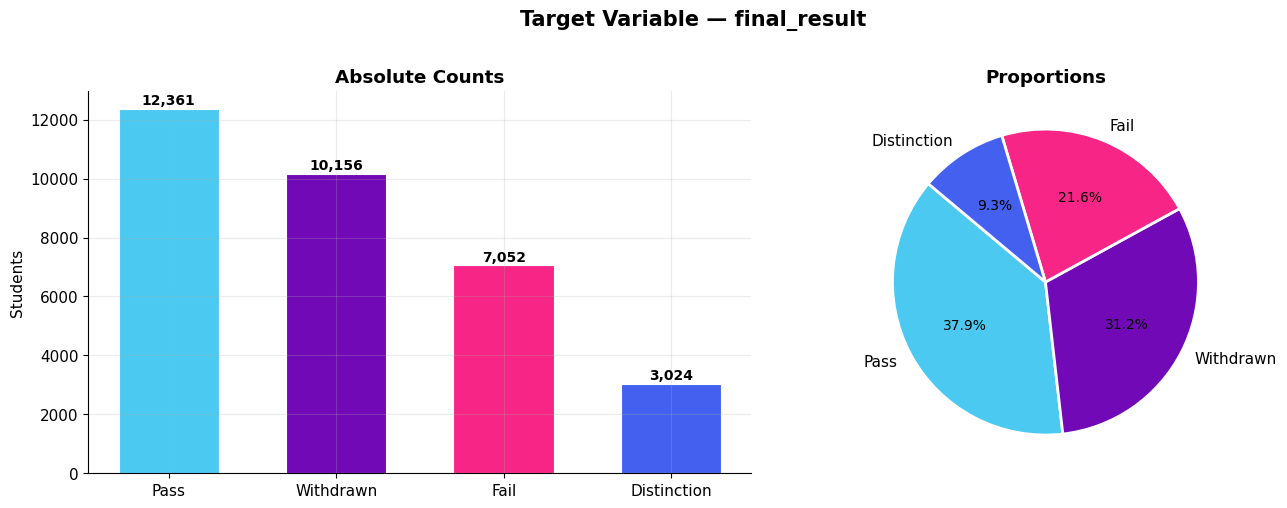


⚖️  CLASS IMBALANCE ANALYSIS
   Success (Pass+Distinction) : 15,385  (47.2%)
   At-Risk (Fail+Withdrawn)   : 17,208  (52.8%)
   Imbalance ratio            : 1.12x  →  SMOTE required


In [6]:
# ── Fig 1 · Target distribution ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Target Variable — final_result', fontsize=15, fontweight='bold', y=1.01)

counts = si['final_result'].value_counts()
c_list = [CLR.get(r, '#888') for r in counts.index]

bars = axes[0].bar(counts.index, counts.values, color=c_list, edgecolor='white', linewidth=.8, width=.6)
axes[0].set_title('Absolute Counts', fontweight='bold')
axes[0].set_ylabel('Students')
for p in bars:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2, p.get_height() + 50),
                     ha='center', va='bottom', fontsize=10, fontweight='bold')

wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=counts.index, colors=c_list,
    autopct='%1.1f%%', startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2})
for at in autotexts: at.set_fontsize(10)
axes[1].set_title('Proportions', fontweight='bold')

plt.tight_layout()
plt.savefig('fig01_target.png', dpi=150, bbox_inches='tight')
plt.show()

# Class imbalance metrics
print('\n⚖️  CLASS IMBALANCE ANALYSIS')
success = counts.get('Pass', 0) + counts.get('Distinction', 0)
atrisk  = counts.get('Fail', 0) + counts.get('Withdrawn', 0)
ratio   = max(success, atrisk) / min(success, atrisk)
print(f'   Success (Pass+Distinction) : {success:,}  ({success/len(si):.1%})')
print(f'   At-Risk (Fail+Withdrawn)   : {atrisk:,}  ({atrisk/len(si):.1%})')
print(f'   Imbalance ratio            : {ratio:.2f}x  →  SMOTE required')


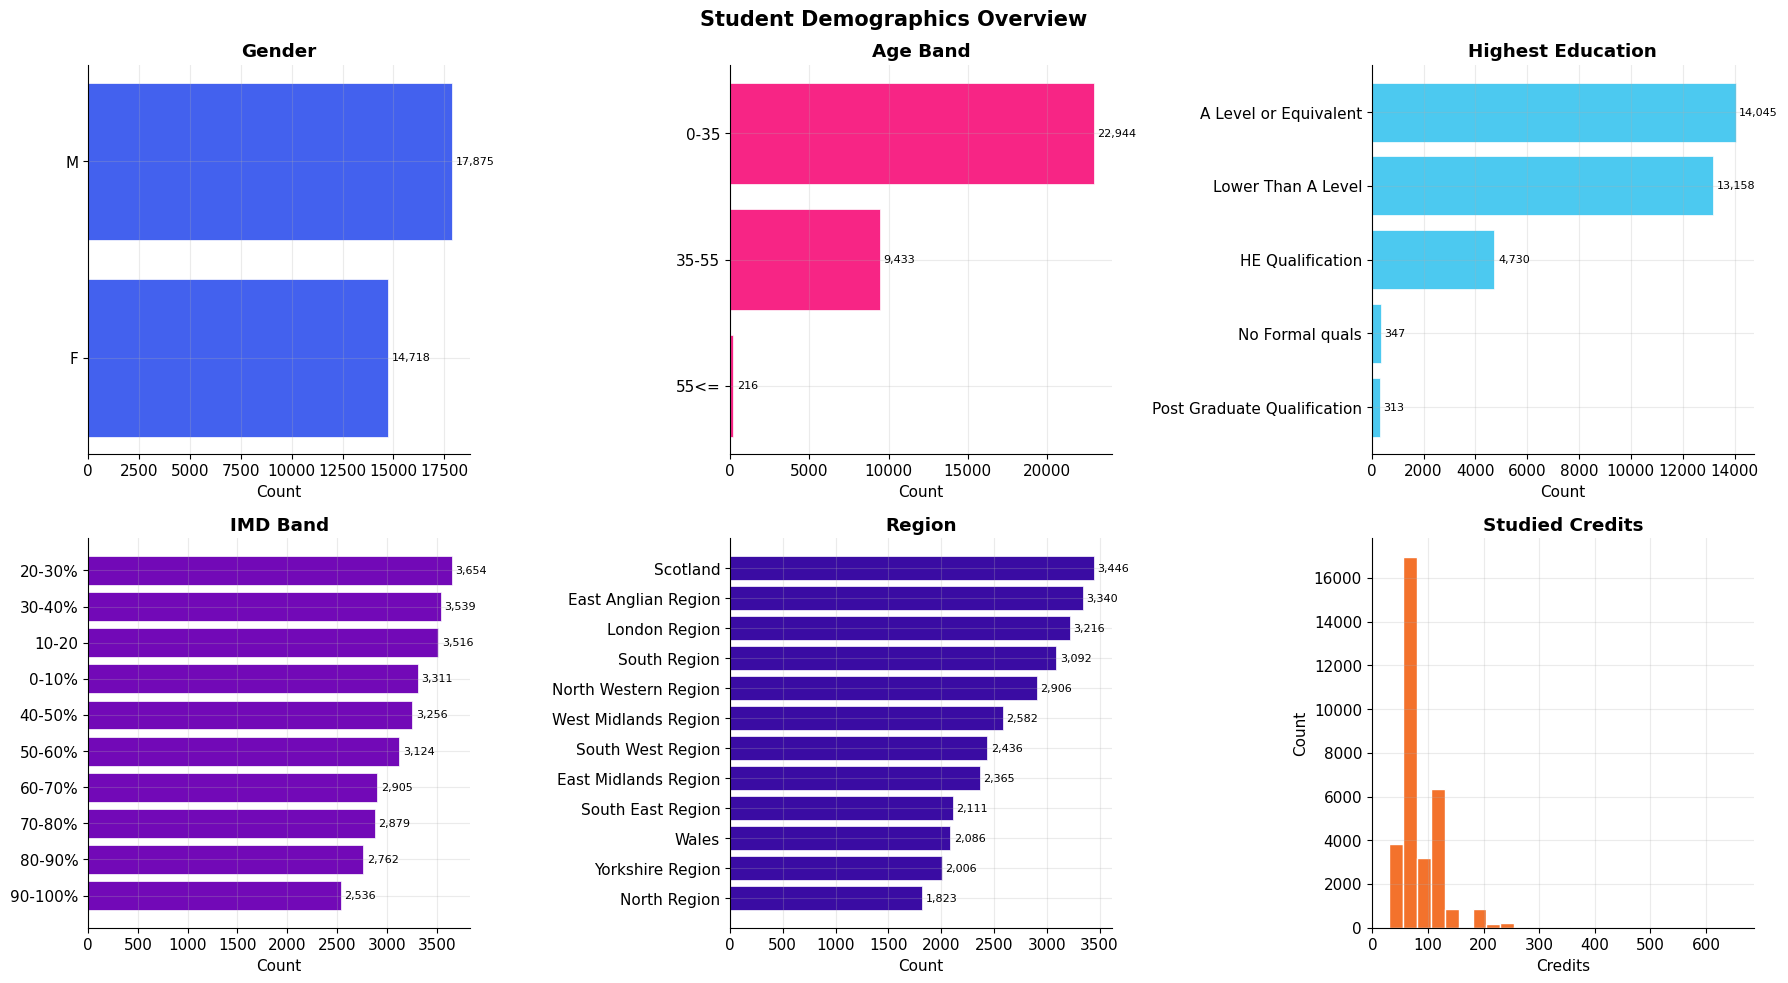

In [7]:
# ── Fig 2 · Demographics overview ───────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Student Demographics Overview', fontsize=15, fontweight='bold')

def bar_h(ax, series, title, top=12, color=None):
    vc = series.value_counts().head(top)
    c  = color or CLR['palette'][0]
    ax.barh(vc.index[::-1], vc.values[::-1], color=c, edgecolor='white', linewidth=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Count')
    for i, (idx, val) in enumerate(zip(vc.index[::-1], vc.values[::-1])):
        ax.text(val + max(vc.values)*0.01, i, f'{val:,}', va='center', fontsize=8)

bar_h(axes[0,0], si['gender'],           'Gender',           color=CLR['palette'][0])
bar_h(axes[0,1], si['age_band'],          'Age Band',         color=CLR['palette'][1])
bar_h(axes[0,2], si['highest_education'], 'Highest Education',color=CLR['palette'][2])
bar_h(axes[1,0], si['imd_band'],          'IMD Band',         color=CLR['palette'][3])
bar_h(axes[1,1], si['region'],            'Region',           color=CLR['palette'][4])

axes[1,2].hist(si['studied_credits'].dropna(), bins=25,
               color=CLR['palette'][5], edgecolor='white')
axes[1,2].set_title('Studied Credits', fontweight='bold')
axes[1,2].set_xlabel('Credits')
axes[1,2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('fig02_demographics.png', dpi=150, bbox_inches='tight')
plt.show()


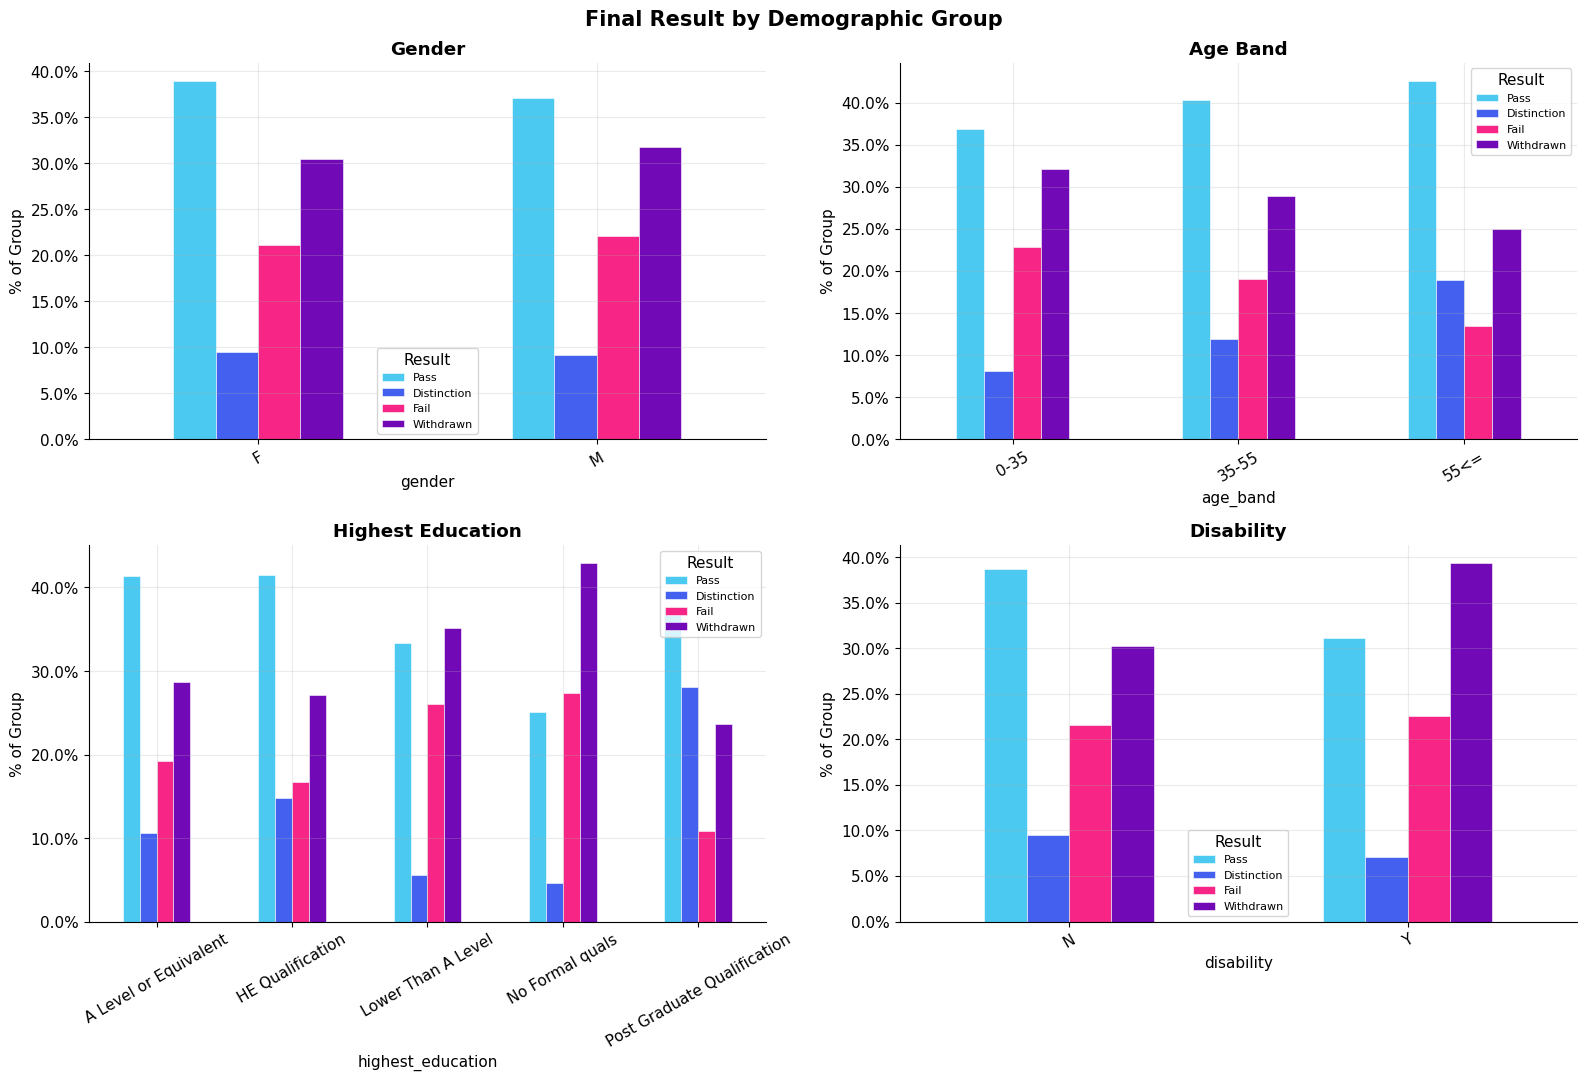

In [8]:
# ── Fig 3 · Result by demographic group ─────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Final Result by Demographic Group', fontsize=15, fontweight='bold')

for ax, col in zip(axes.flatten(), ['gender', 'age_band', 'highest_education', 'disability']):
    ct = (pd.crosstab(si[col], si['final_result'], normalize='index') * 100
          ).reindex(columns=['Pass','Distinction','Fail','Withdrawn'], fill_value=0)
    ct.plot(kind='bar', ax=ax, color=[CLR.get(c, '#888') for c in ct.columns],
            edgecolor='white', linewidth=.4)
    ax.set_title(col.replace('_',' ').title(), fontweight='bold')
    ax.set_ylabel('% of Group')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend(title='Result', fontsize=8)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('fig03_result_by_demo.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 📊 SECTION 3 — EDA: VLE & Assessments

Aggregating VLE data …


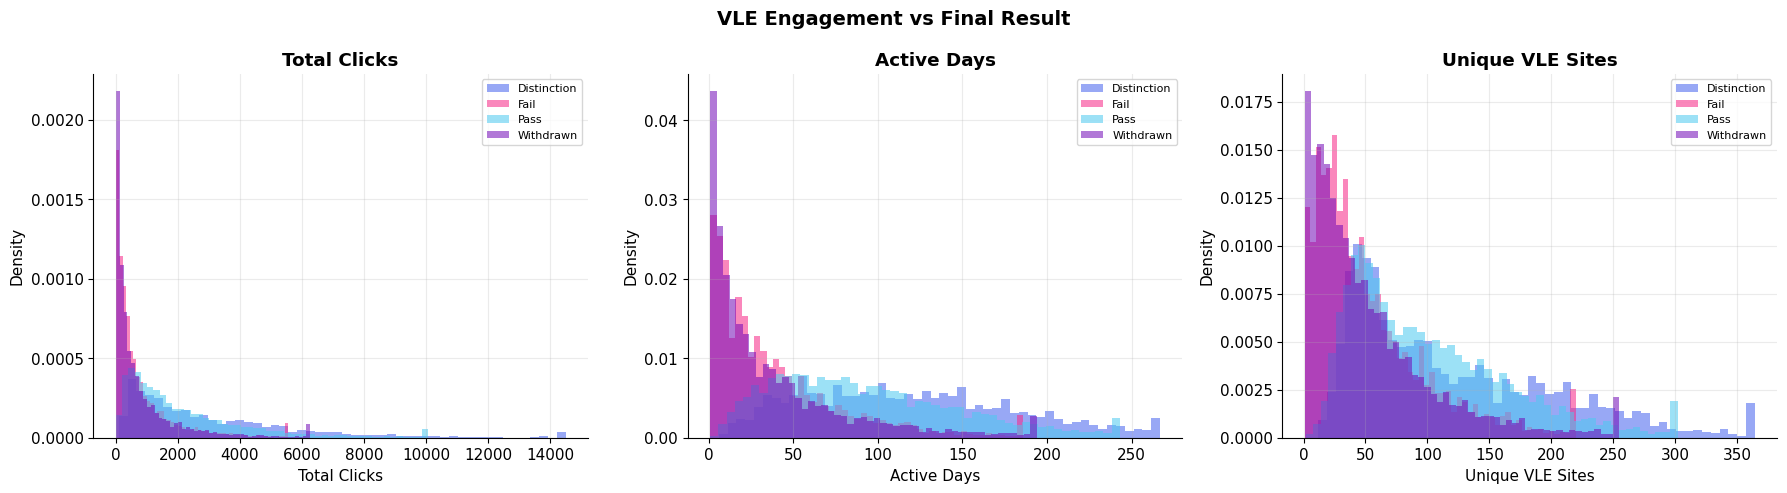

In [9]:
# ── VLE quick aggregate ──────────────────────────────────────
print('Aggregating VLE data …')
vle_quick = sv.groupby('id_student').agg(
    total_clicks = ('sum_click', 'sum'),
    active_days  = ('date', 'nunique'),
    unique_sites = ('id_site', 'nunique'),
).reset_index()
si_v = si.merge(vle_quick, on='id_student', how='left')

# ── Fig 4 · VLE engagement ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('VLE Engagement vs Final Result', fontsize=14, fontweight='bold')

for ax, col, label in zip(axes,
    ['total_clicks', 'active_days', 'unique_sites'],
    ['Total Clicks',  'Active Days', 'Unique VLE Sites']):
    for res, grp in si_v.groupby('final_result'):
        d = grp[col].clip(upper=grp[col].quantile(.99))
        ax.hist(d, bins=50, alpha=.55, density=True, edgecolor='none',
                label=res, color=CLR.get(res, '#888'))
    ax.set_xlabel(label); ax.set_ylabel('Density')
    ax.set_title(label, fontweight='bold'); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig04_vle_engagement.png', dpi=150, bbox_inches='tight')
plt.show()


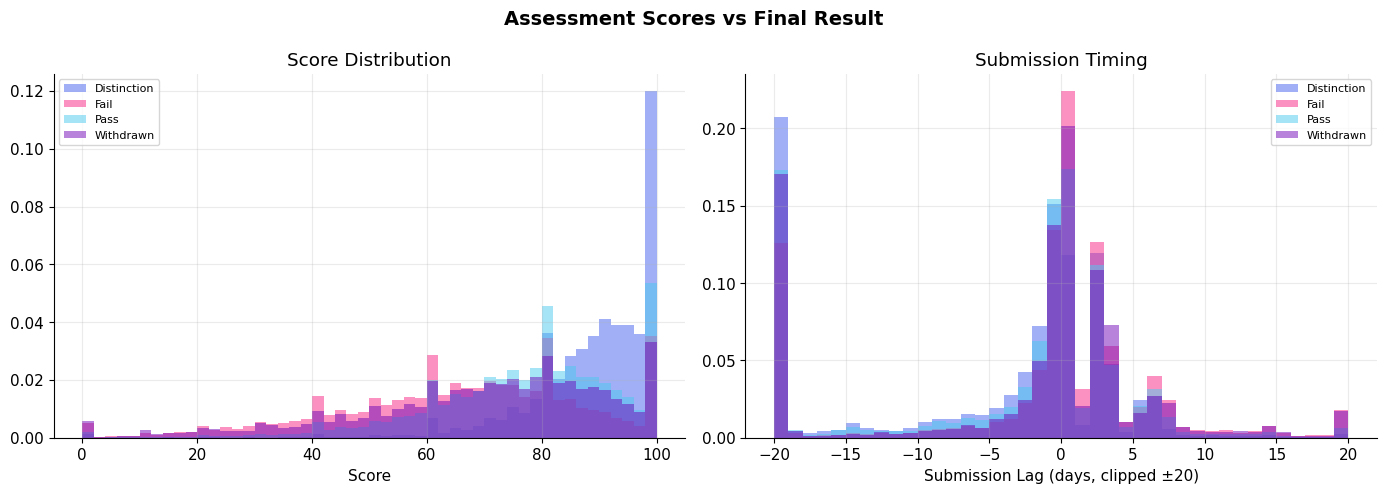

In [10]:
# ── Fig 5 · Assessments ──────────────────────────────────────
sa_m = sa.merge(si[['id_student', 'final_result']], on='id_student', how='left')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Assessment Scores vs Final Result', fontsize=14, fontweight='bold')

for res, grp in sa_m.groupby('final_result'):
    axes[0].hist(grp['score'].dropna(), bins=50, alpha=.5, density=True,
                 edgecolor='none', label=res, color=CLR.get(res, '#888'))
axes[0].set_xlabel('Score'); axes[0].set_title('Score Distribution'); axes[0].legend(fontsize=8)

sa_m2 = sa_m.merge(asmts[['id_assessment','date']].rename(columns={'date':'due_date'}),
                   on='id_assessment', how='left')
sa_m2['lag'] = sa_m2['date_submitted'] - sa_m2['due_date']
for res, grp in sa_m2.groupby('final_result'):
    axes[1].hist(grp['lag'].dropna().clip(-20, 20), bins=40, alpha=.5, density=True,
                 edgecolor='none', label=res, color=CLR.get(res, '#888'))
axes[1].set_xlabel('Submission Lag (days, clipped ±20)')
axes[1].set_title('Submission Timing'); axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig05_assessments.png', dpi=150, bbox_inches='tight')
plt.show()


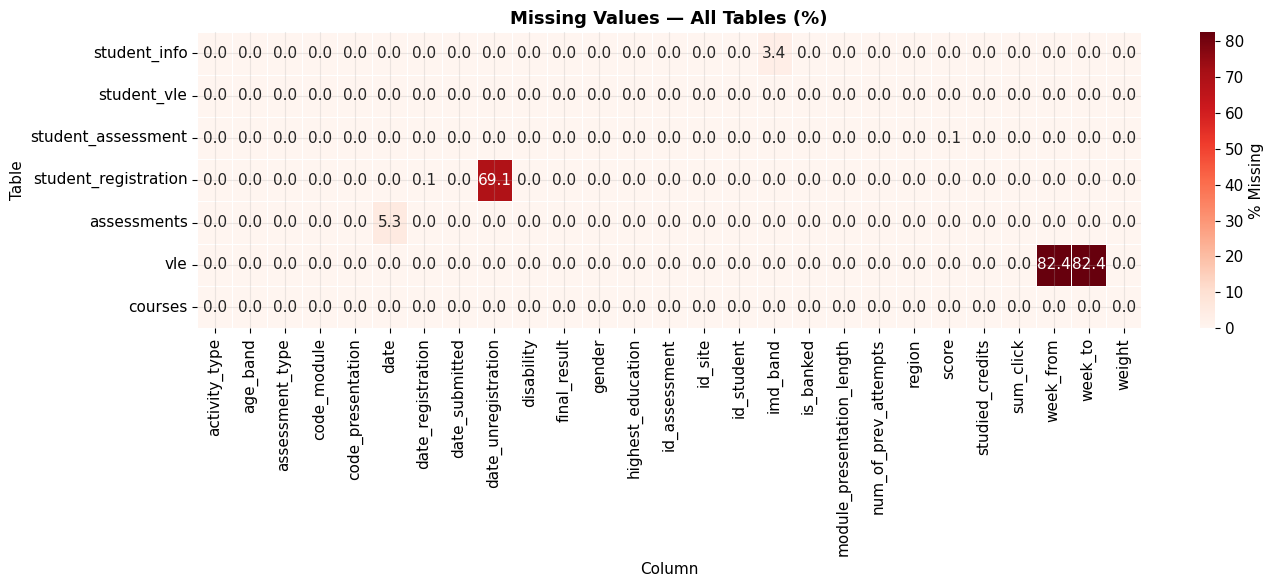

✅  EDA complete — 6 figures saved


In [11]:
# ── Fig 6 · Missing values heatmap ──────────────────────────
all_miss = {name: (df.isnull().mean()*100).rename(name) for name, df in T.items()}
miss_df  = pd.DataFrame(all_miss).fillna(0)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(miss_df.T, annot=True, fmt='.1f', cmap='Reds',
            linewidths=.5, ax=ax, cbar_kws={'label': '% Missing'})
ax.set_title('Missing Values — All Tables (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Column'); ax.set_ylabel('Table')
plt.tight_layout()
plt.savefig('fig06_missing_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅  EDA complete — 6 figures saved')


---
## 🔧 SECTION 4 — Advanced Cleaning & Encoding

In [12]:
# ════════════════════════════════════════════════════════════
# PROFESSIONAL ENCODING STRATEGY:
#  • Ordinal  → imd_band, highest_education, age_band
#  • Binary   → gender, disability
#  • One-Hot  → code_module, region (moderate cardinality)
#  • Target   → code_presentation (high-cardinality, leakage-safe)
# ════════════════════════════════════════════════════════════

from sklearn.preprocessing import OrdinalEncoder

# Ordinal mappings
IMD_ORDER = ['0-10%','10-20%','20-30%','30-40%','40-50%',
             '50-60%','60-70%','70-80%','80-90%','90-100%']
EDU_ORDER = ['No Formal quals','Lower Than A Level',
             'A Level or Equivalent','HE Qualification',
             'Post Graduate Qualification']
AGE_ORDER = ['0-35','35-55','55<=']

def clean_and_encode(df, fit_encoders=True, encoders=None):
    """
    Full professional cleaning + encoding pipeline.
    fit_encoders=True  → fit on train, return (df, encoders)
    fit_encoders=False → transform with supplied encoders
    """
    df = df.copy()
    enc = encoders or {}

    # 1. Deduplicate
    before = len(df)
    df.drop_duplicates(inplace=True)
    print(f'  Duplicates removed : {before - len(df)}')

    # 2. Standardise string columns
    str_cols = df.select_dtypes('object').columns
    for c in str_cols:
        df[c] = df[c].str.strip()

    # 3. IMD band — missing → regional mode → ordinal
    df['imd_band'] = (
        df.groupby('region')['imd_band']
          .transform(lambda x: x.fillna(x.mode()[0] if len(x.mode()) else 'Unknown'))
    )
    df['imd_band'] = df['imd_band'].fillna('Unknown')

    imd_map = {v: i for i, v in enumerate(IMD_ORDER)}
    imd_map['Unknown'] = -1
    df['imd_num'] = df['imd_band'].map(imd_map).fillna(-1).astype(int)

    # 4. Education — ordinal
    edu_map = {v: i for i, v in enumerate(EDU_ORDER)}
    df['edu_num'] = df['highest_education'].map(edu_map).fillna(-1).astype(int)

    # 5. Age — ordinal
    age_map = {v: i for i, v in enumerate(AGE_ORDER)}
    df['age_num'] = df['age_band'].map(age_map).fillna(-1).astype(int)

    # 6. Binary flags
    df['is_male']     = (df['gender']     == 'M').astype(int)
    df['is_disabled'] = (df['disability'] == 'Y').astype(int)

    # 7. Targets — build BEFORE encoding code_presentation
    label4 = {'Pass': 0, 'Distinction': 1, 'Fail': 2, 'Withdrawn': 3}
    df['target_4']   = df['final_result'].map(label4)
    df['target_bin'] = df['final_result'].apply(
        lambda x: 0 if x in ['Pass','Distinction'] else 1)

    # 8. One-hot: module + region (known cardinality, safe)
    df = pd.get_dummies(df, columns=['code_module', 'region'],
                        drop_first=True, dtype=int)

    # 9. Label-encode code_presentation (ordinal-ish: year+semester)
    if fit_encoders:
        le = LabelEncoder()
        df['presentation_enc'] = le.fit_transform(df['code_presentation'].astype(str))
        enc['presentation_le'] = le
    else:
        le  = enc['presentation_le']
        df['presentation_enc'] = df['code_presentation'].astype(str).apply(
            lambda x: le.transform([x])[0] if x in le.classes_ else -1)

    # 10. Drop raw categoricals (already encoded)
    drop_raw = ['final_result','gender','age_band','highest_education',
                'imd_band','disability','code_presentation']
    df.drop(columns=[c for c in drop_raw if c in df.columns], inplace=True)

    print(f'  Shape after encoding: {df.shape}')
    return (df, enc) if fit_encoders else df

print('\n🔧  Cleaning & encoding studentInfo …')
si_c, ENCODERS = clean_and_encode(si, fit_encoders=True)
print(si_c[['target_4','target_bin','is_male','is_disabled','imd_num','edu_num','age_num','presentation_enc']].head())
print('\n✅  Encoding complete')
print(f'   Ordinal columns    : imd_num, edu_num, age_num')
print(f'   Binary columns     : is_male, is_disabled')
print(f'   Label-encoded      : presentation_enc')
print(f'   One-hot columns    : {[c for c in si_c.columns if c.startswith(("code_module_","region_"))][:5]} …')



🔧  Cleaning & encoding studentInfo …
  Duplicates removed : 0
  Shape after encoding: (32593, 29)
   target_4  target_bin  is_male  is_disabled  imd_num  edu_num  age_num  \
0         0           0        1            0        9        3        2   
1         0           0        0            0        2        3        1   
2         3           1        0            1        3        2        1   
3         0           0        0            0        5        2        1   
4         0           0        0            0        5        1        0   

   presentation_enc  
0                 1  
1                 1  
2                 1  
3                 1  
4                 1  

✅  Encoding complete
   Ordinal columns    : imd_num, edu_num, age_num
   Binary columns     : is_male, is_disabled
   Label-encoded      : presentation_enc
   One-hot columns    : ['code_module_BBB', 'code_module_CCC', 'code_module_DDD', 'code_module_EEE', 'code_module_FFF'] …


--- 
## 🧪 SECTION 5 — Advanced Feature Engineering (All 7 Tables)
> استخراج كل إمكانية من الداتا: VLE windows, registration timing, module-normalized features, on-schedule ratio


In [13]:
print('\n⚙️  Engineering features — ALL TABLES …\n')

EARLY_DAY  = 14    # first 2 weeks
MID_DAY    = 100   # midpoint
LATE_DAY   = 200   # late stage
FAIL_SCORE = 40    # passing threshold

# ══════════════════════════════════════════════════════
# 0. MODULE LENGTH — from courses table (was 100% missed)
#    Critical normalizer: clicks in a 30-week course ≠ clicks in a 20-week course
# ══════════════════════════════════════════════════════
course_len = T['courses'][['code_module','code_presentation','module_presentation_length']].copy()

# Merge module length into si so we can normalize per-student
si_with_len = si.merge(course_len, on=['code_module','code_presentation'], how='left')
si_with_len['module_length'] = si_with_len['module_presentation_length'].fillna(
    si_with_len['module_presentation_length'].median()
)
module_len_map = si_with_len.set_index('id_student')['module_length'].to_dict()

print(f'  Module lengths range: {course_len["module_presentation_length"].min()} – '
      f'{course_len["module_presentation_length"].max()} weeks')
print(f'  Unique course configs: {len(course_len)}')

# ══════════════════════════════════════════════════════
# A. VLE FEATURES — engagement patterns + weekly windows
# ══════════════════════════════════════════════════════
vle_base = sv.groupby('id_student').agg(
    total_clicks     = ('sum_click', 'sum'),
    active_days      = ('date', 'nunique'),
    unique_sites     = ('id_site', 'nunique'),
    avg_daily_clicks = ('sum_click', 'mean'),
    max_daily_clicks = ('sum_click', 'max'),
    std_daily_clicks = ('sum_click', 'std'),
    first_activity   = ('date', 'min'),
    last_activity    = ('date', 'max'),
).reset_index()

# Add module length per student
vle_base['module_length'] = vle_base['id_student'].map(module_len_map).fillna(
    course_len['module_presentation_length'].median()
)

# Temporal segments
early = (sv[sv['date'] <= EARLY_DAY]
         .groupby('id_student')
         .agg(early_clicks=('sum_click','sum'),
              early_days  =('date','nunique'))
         .reset_index())

mid   = (sv[(sv['date'] > EARLY_DAY) & (sv['date'] <= MID_DAY)]
         .groupby('id_student')
         .agg(mid_clicks=('sum_click','sum'),
              mid_days  =('date','nunique'))
         .reset_index())

late  = (sv[sv['date'] > LATE_DAY]
         .groupby('id_student')
         .agg(late_clicks=('sum_click','sum'),
              late_days  =('date','nunique'))
         .reset_index())

# Activity-type diversity
sv_typed = sv.merge(vle[['id_site','activity_type']], on='id_site', how='left')
act_div = (sv_typed.groupby('id_student')['activity_type']
                   .nunique().reset_index()
                   .rename(columns={'activity_type': 'activity_types_visited'}))

# Clicks by activity type
act_pivot = (sv_typed.groupby(['id_student','activity_type'])['sum_click']
                     .sum().unstack(fill_value=0).reset_index())
act_pivot.columns = ['id_student'] + [f'act_{c}' for c in act_pivot.columns[1:]]

# ── ON-SCHEDULE ratio using week_from / week_to (was missed!) ──
# For each VLE resource, week_from/week_to define when it's relevant.
# A student clicking it within that window = on-schedule.
vle_schedule = vle[['id_site','week_from','week_to']].dropna(subset=['week_from','week_to'])
sv_sched = sv.merge(vle_schedule, on='id_site', how='inner')
# Convert days to weeks (OULAD date is days since start)
sv_sched['week_of_click'] = sv_sched['date'] / 7
sv_sched['on_schedule']   = (
    (sv_sched['week_of_click'] >= sv_sched['week_from']) &
    (sv_sched['week_of_click'] <= sv_sched['week_to'] + 1)  # +1 week grace
).astype(int)

sched_feat = (sv_sched.groupby('id_student').agg(
    on_schedule_clicks = ('on_schedule', lambda x: (x * sv_sched.loc[x.index,'sum_click']).sum()),
    total_sched_clicks = ('sum_click', 'sum'),
).reset_index())
sched_feat['on_schedule_ratio'] = (
    sched_feat['on_schedule_clicks'] / (sched_feat['total_sched_clicks'] + 1)
)

# Merge all VLE features
vle_feat = (vle_base
            .merge(early,      on='id_student', how='left')
            .merge(mid,        on='id_student', how='left')
            .merge(late,       on='id_student', how='left')
            .merge(act_div,    on='id_student', how='left')
            .merge(act_pivot,  on='id_student', how='left')
            .merge(sched_feat, on='id_student', how='left')
            .fillna(0))

# ── Derived ratios & normalized features ──────────────────────
vle_feat['early_click_ratio']   = vle_feat['early_clicks'] / (vle_feat['total_clicks'] + 1)
vle_feat['late_click_ratio']    = vle_feat['late_clicks']  / (vle_feat['total_clicks'] + 1)
vle_feat['mid_click_ratio']     = vle_feat['mid_clicks']   / (vle_feat['total_clicks'] + 1)
vle_feat['clicks_per_day']      = vle_feat['total_clicks'] / (vle_feat['active_days']  + 1)
vle_feat['site_diversity']      = vle_feat['unique_sites'] / (vle_feat['active_days']  + 1)
vle_feat['activity_span']       = vle_feat['last_activity'] - vle_feat['first_activity']
vle_feat['std_daily_clicks']    = vle_feat['std_daily_clicks'].fillna(0)
vle_feat['click_consistency']   = vle_feat['avg_daily_clicks'] / (vle_feat['std_daily_clicks'] + 1)
vle_feat['engaged_early']       = (vle_feat['early_days'] >= 3).astype(int)

# MODULE-NORMALIZED features (uses courses table — was 100% missing!)
vle_feat['clicks_per_week']     = vle_feat['total_clicks'] / (vle_feat['module_length'] + 1)
vle_feat['active_day_ratio']    = vle_feat['active_days']  / (vle_feat['module_length'] * 7 + 1)
vle_feat['sites_per_week']      = vle_feat['unique_sites'] / (vle_feat['module_length'] + 1)

print(f'  VLE features    : {vle_feat.shape[1]-1}')
print(f'  → incl. on_schedule_ratio, clicks_per_week, active_day_ratio (NEW)')



⚙️  Engineering features — ALL TABLES …

  Module lengths range: 234 – 269 weeks
  Unique course configs: 22
  VLE features    : 50
  → incl. on_schedule_ratio, clicks_per_week, active_day_ratio (NEW)


In [14]:
# ════════════════════════════════════════
# B. ASSESSMENT FEATURES — performance
# ════════════════════════════════════════
sa_full = sa.merge(asmts[['id_assessment','assessment_type','weight','date']],
                   on='id_assessment', how='left')
sa_full['lag'] = sa_full['date_submitted'] - sa_full['date']
sa_full['weighted_score'] = sa_full['score'] * sa_full['weight'].fillna(1)

# Score trend: +slope = improving, -slope = declining
def score_slope(grp):
    g = grp.sort_values('date').dropna(subset=['score'])
    if len(g) < 2: return 0.0
    return float(np.polyfit(np.arange(len(g)), g['score'].values, 1)[0])

# Score momentum: last 2 vs first 2 assessments
def score_momentum(grp):
    g = grp.sort_values('date')['score'].dropna()
    if len(g) < 4: return 0.0
    return g.iloc[-2:].mean() - g.iloc[:2].mean()

slopes   = (sa_full.groupby('id_student').apply(score_slope)
                   .reset_index().rename(columns={0:'score_trend'}))
momentum = (sa_full.groupby('id_student').apply(score_momentum)
                   .reset_index().rename(columns={0:'score_momentum'}))

# TMA vs CMA separation (different assessment types)
tma = (sa_full[sa_full['assessment_type']=='TMA']
       .groupby('id_student')['score'].mean()
       .reset_index().rename(columns={'score':'tma_avg_score'}))

cma = (sa_full[sa_full['assessment_type']=='CMA']
       .groupby('id_student')['score'].mean()
       .reset_index().rename(columns={'score':'cma_avg_score'}))

asmt_feat = (sa_full.groupby('id_student').agg(
    avg_score            = ('score',          'mean'),
    std_score            = ('score',          'std'),
    min_score            = ('score',          'min'),
    max_score            = ('score',          'max'),
    n_assessments        = ('id_assessment',  'count'),
    avg_lag              = ('lag',            'mean'),
    late_count           = ('lag',            lambda x: (x < 0).sum()),
    on_time_count        = ('lag',            lambda x: (x >= 0).sum()),
    unsubmitted_count    = ('is_banked',      lambda x: (x == 0).sum()),
    weighted_avg_score   = ('weighted_score', 'sum'),
).reset_index()
.merge(slopes,   on='id_student', how='left')
.merge(momentum, on='id_student', how='left')
.merge(tma,      on='id_student', how='left')
.merge(cma,      on='id_student', how='left')
.fillna(0))

# Fail count & ratio
asmt_feat['fail_count'] = (
    sa_full[sa_full['score'] < FAIL_SCORE]
    .groupby('id_student')['id_assessment']
    .count().reindex(asmt_feat['id_student'], fill_value=0).values)

asmt_feat['fail_ratio'] = asmt_feat['fail_count'] / (asmt_feat['n_assessments'] + 1)
asmt_feat['on_time_ratio'] = asmt_feat['on_time_count'] / (asmt_feat['n_assessments'] + 1)
asmt_feat['score_range'] = asmt_feat['max_score'] - asmt_feat['min_score']

print(f'  Assessment feat : {asmt_feat.shape[1]-1}')


  Assessment feat : 18


In [15]:
# ════════════════════════════════════════
# C. REGISTRATION FEATURES (date_registration was missed!)
# ════════════════════════════════════════

# Get module start date per course as reference point
# OULAD uses date=0 as module start; date_registration is days before/after
# Negative = registered before start (motivated), Positive = late registration
reg_base = reg.copy()
reg_base['withdrew']        = reg_base['date_unregistration'].notna().astype(int)
reg_base['days_to_withd']   = reg_base['date_unregistration'].fillna(9999)

# date_registration: negative = early signup, 0 = start, positive = late
reg_base['registered_early']  = (reg_base['date_registration'] < 0).astype(int)
reg_base['registered_late']   = (reg_base['date_registration'] > 7).astype(int)
reg_base['days_before_start'] = reg_base['date_registration'].clip(upper=0).abs()  # 0 if late

reg_feat = (reg_base
            .groupby('id_student')
            .agg(
                n_modules         = ('code_module',     'count'),
                withdrew_any      = ('withdrew',        'max'),
                earliest_withd    = ('days_to_withd',   'min'),
                avg_reg_timing    = ('date_registration','mean'),   # NEW
                earliest_reg      = ('date_registration','min'),    # NEW: most proactive
                registered_early  = ('registered_early', 'max'),    # NEW
                registered_late   = ('registered_late',  'max'),    # NEW
                avg_days_before   = ('days_before_start','mean'),   # NEW
            )
            .reset_index())

print(f'  Registration features: {reg_feat.shape[1]-1}  (incl. 4 NEW timing features)')

# ════════════════════════════════════════
# D. MERGE ALL FEATURES → MASTER
# ════════════════════════════════════════
drop_si = ['final_result','gender','age_band','highest_education',
           'imd_band','disability','code_presentation']
si_feats = si_c.drop(columns=drop_si, errors='ignore')

master = (si_feats
          .merge(vle_feat,  on='id_student', how='left')
          .merge(asmt_feat, on='id_student', how='left')
          .merge(reg_feat,  on='id_student', how='left')
          .fillna(0))

print(f'\n✅  Master shape   : {master.shape[0]:,} rows × {master.shape[1]} cols')
print(f'   Binary  balance : {master["target_bin"].value_counts().to_dict()}')
print(f'   4-class balance : {master["target_4"].value_counts().to_dict()}')

# ── Cross-table interaction features ────────────────────────
# Original interactions
master['engagement_score_interaction'] = master['total_clicks']   * master['avg_score'] / (master['n_assessments'] + 1)
master['early_engagement_x_edu']       = master['early_clicks']   * master['edu_num']
master['consistency_x_score']          = master['click_consistency'] * master['avg_score']
master['fail_ratio_x_late_count']      = master['fail_ratio']     * master['late_count']

# NEW interactions using previously-missed features
master['reg_timing_x_early_clicks']    = master['avg_reg_timing'].abs() * master['early_clicks']
master['on_schedule_x_avg_score']      = master['on_schedule_ratio']   * master['avg_score']
master['clicks_per_week_x_score']      = master['clicks_per_week']     * master['avg_score']
master['active_ratio_x_on_schedule']   = master['active_day_ratio']    * master['on_schedule_ratio']

print(f'   With interactions  : {master.shape[1]} total features')
print(f'\n   NEW features added:')
print(f'   ✅ clicks_per_week      (normalized by module_presentation_length)')
print(f'   ✅ active_day_ratio     (normalized by module_presentation_length)')
print(f'   ✅ on_schedule_ratio    (using week_from / week_to from vle)')
print(f'   ✅ avg_reg_timing       (using date_registration — motivation signal)')
print(f'   ✅ registered_early     (proactive enrollment flag)')
print(f'   ✅ avg_days_before      (days before module start)')


  Registration features: 8  (incl. 4 NEW timing features)

✅  Master shape   : 32,593 rows × 105 cols
   Binary  balance : {1: 17208, 0: 15385}
   4-class balance : {0: 12361, 3: 10156, 2: 7052, 1: 3024}
   With interactions  : 113 total features

   NEW features added:
   ✅ clicks_per_week      (normalized by module_presentation_length)
   ✅ active_day_ratio     (normalized by module_presentation_length)
   ✅ on_schedule_ratio    (using week_from / week_to from vle)
   ✅ avg_reg_timing       (using date_registration — motivation signal)
   ✅ registered_early     (proactive enrollment flag)
   ✅ avg_days_before      (days before module start)


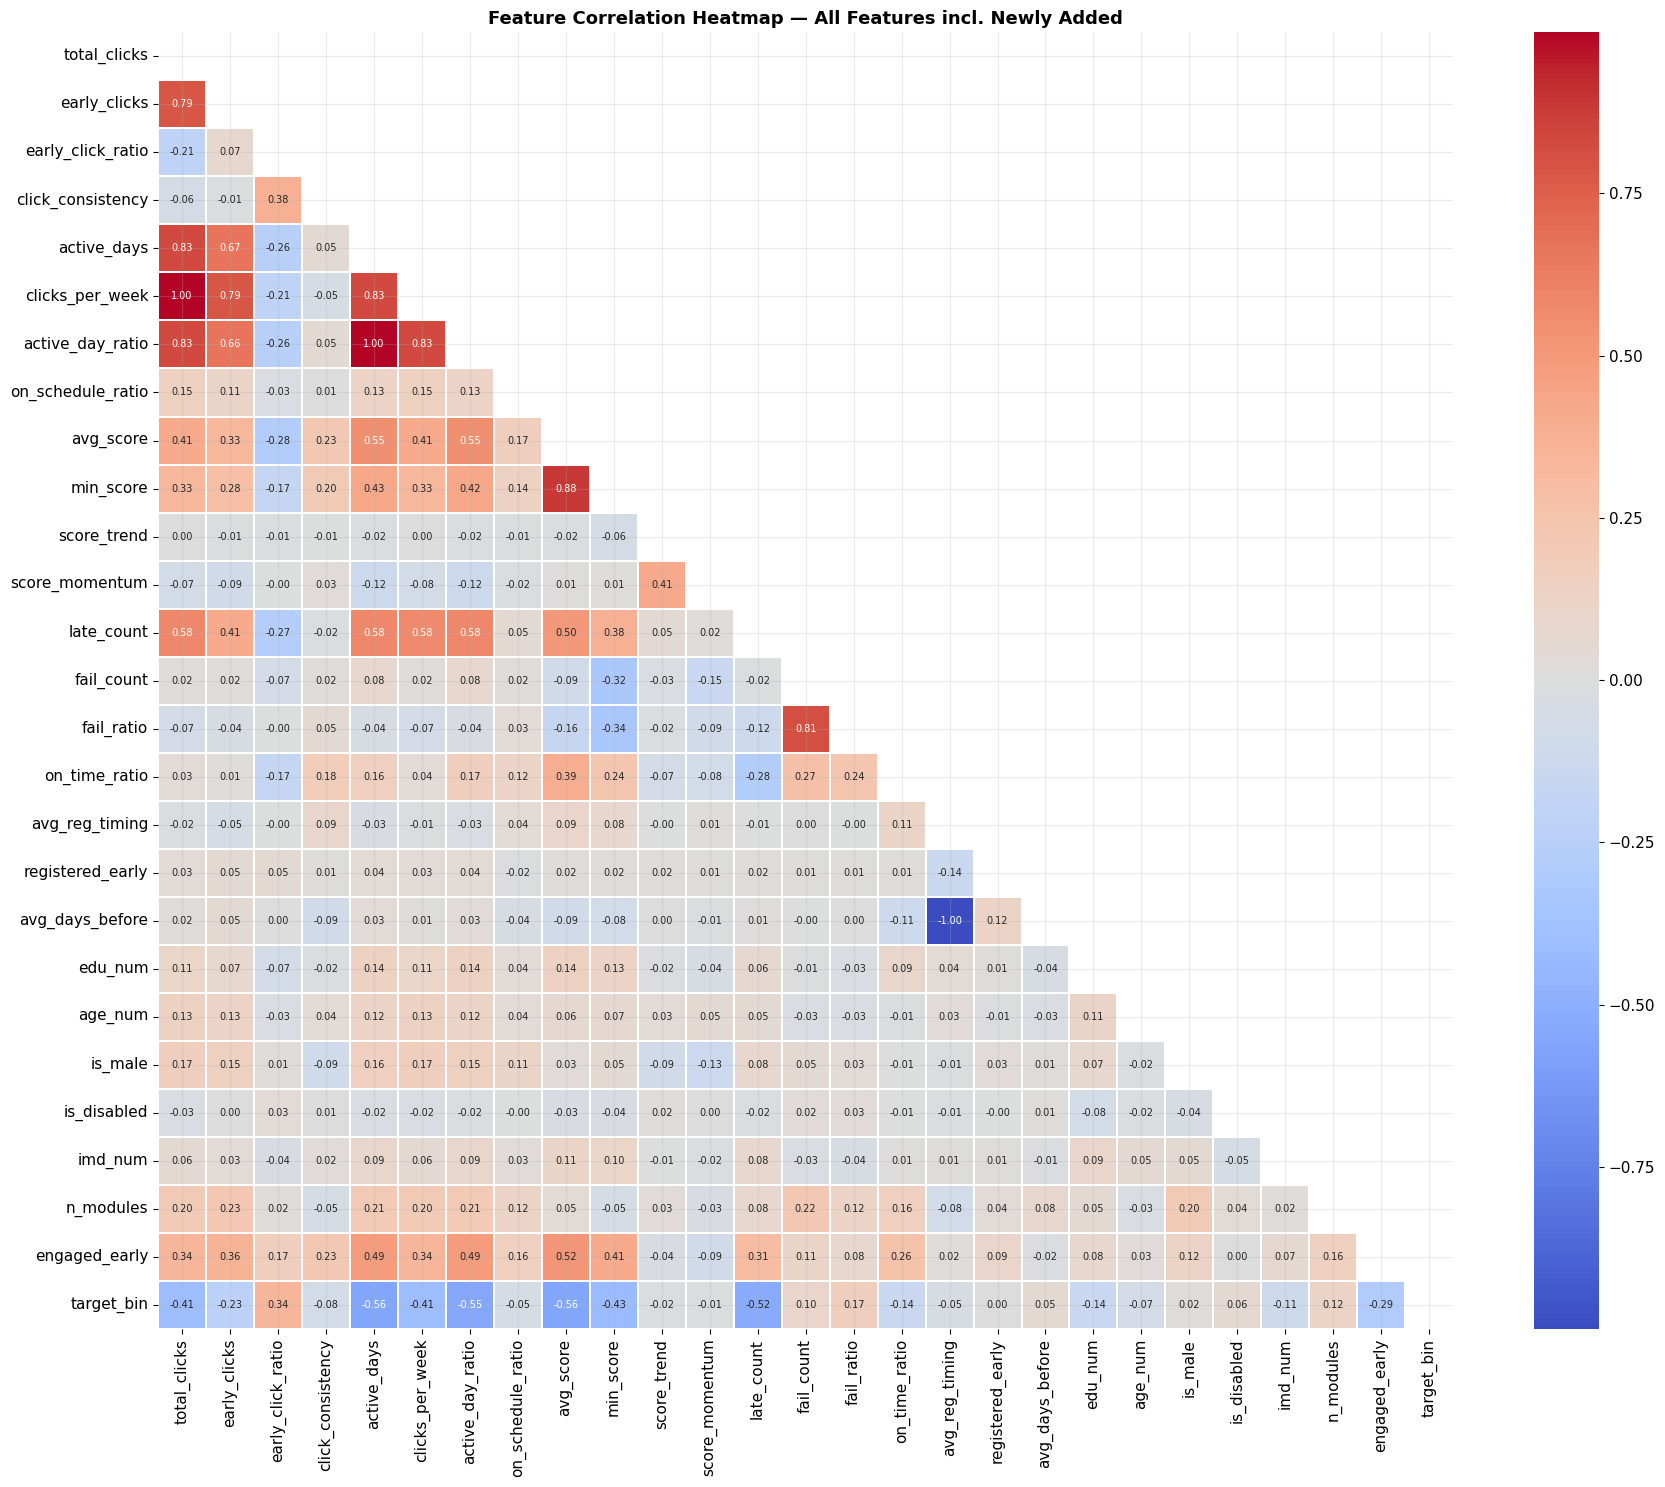


📊  Top 15 features correlated with target_bin:
avg_score           -0.559
active_days         -0.556
active_day_ratio    -0.554
late_count          -0.524
min_score           -0.429
total_clicks        -0.412
clicks_per_week     -0.411
early_click_ratio    0.344
engaged_early       -0.291
early_clicks        -0.231
fail_ratio           0.168
on_time_ratio       -0.145
edu_num             -0.144
n_modules            0.118
imd_num             -0.107


In [16]:
# ── Fig 7 · Correlation heatmap ──────────────────────────────
key_feats = [
    # VLE
    'total_clicks','early_clicks','early_click_ratio','click_consistency',
    'active_days','clicks_per_week','active_day_ratio','on_schedule_ratio',
    # Assessment
    'avg_score','min_score','score_trend','score_momentum',
    'late_count','fail_count','fail_ratio','on_time_ratio',
    # Registration (NEW)
    'avg_reg_timing','registered_early','avg_days_before',
    # Demographics
    'edu_num','age_num','is_male','is_disabled','imd_num',
    'n_modules','engaged_early',
    # Target
    'target_bin'
]
key_feats = [f for f in key_feats if f in master.columns]

fig, ax = plt.subplots(figsize=(18, 15))
corr = master[key_feats].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=.3, ax=ax, annot_kws={'size': 7})
ax.set_title('Feature Correlation Heatmap — All Features incl. Newly Added',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig07_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Correlation with target specifically ──────────────────────
target_corr = master[key_feats].corr()['target_bin'].drop('target_bin').sort_values(key=abs, ascending=False)
print('\n📊  Top 15 features correlated with target_bin:')
print(target_corr.head(15).to_string())


---
## 🤖 SECTION 6 — Modeling Pipeline (No Data Leakage)

In [17]:
from sklearn.model_selection  import train_test_split, StratifiedKFold, cross_val_score, learning_curve
from sklearn.preprocessing    import StandardScaler
from sklearn.metrics          import (
    accuracy_score, f1_score, roc_auc_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,
    precision_recall_curve, average_precision_score
)
from imblearn.over_sampling   import SMOTE
from imblearn.pipeline        import Pipeline as ImbPipe

# ── Train / Test split ───────────────────────────────────────
drop_cols = ['id_student', 'target_bin', 'target_4']
X = master.drop(columns=drop_cols, errors='ignore').select_dtypes(include=np.number)
y = master['target_bin']   # 0=success, 1=at-risk

# Remove any inf or extreme values
X = X.replace([np.inf, -np.inf], 0).fillna(0)

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=.2, stratify=y, random_state=SEED)

print(f'Train : {X_tr.shape}  |  Test : {X_te.shape}')
print(f'Pos rate train : {y_tr.mean():.2%}  |  Pos rate test : {y_te.mean():.2%}')
print(f'Total features : {X_tr.shape[1]}')

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def make_pipe(model, scale=False, sampler=None):
    """Leakage-safe pipeline: SMOTE inside CV fold only."""
    samp = sampler or SMOTE(random_state=SEED)
    steps = [('smote', samp)]
    if scale:
        steps.append(('scaler', StandardScaler()))
    steps.append(('model', model))
    return ImbPipe(steps)

print('\n✅  Data split ready — pipelines configured')


Train : (26074, 110)  |  Test : (6519, 110)
Pos rate train : 52.80%  |  Pos rate test : 52.80%
Total features : 110

✅  Data split ready — pipelines configured


In [18]:
# ── Model definitions ────────────────────────────────────────
MODELS = {
    'Logistic Regression': make_pipe(
        LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced', random_state=SEED),
        scale=True),

    'Decision Tree': make_pipe(
        DecisionTreeClassifier(max_depth=8, min_samples_leaf=20,
                               class_weight='balanced', random_state=SEED)),

    'Random Forest': make_pipe(
        RandomForestClassifier(n_estimators=300, max_depth=15,
                               min_samples_leaf=10, class_weight='balanced',
                               n_jobs=-1, random_state=SEED)),

    'Gradient Boosting': make_pipe(
        GradientBoostingClassifier(n_estimators=200, learning_rate=.05,
                                   max_depth=5, random_state=SEED)),

    'XGBoost': make_pipe(
        xgb.XGBClassifier(n_estimators=300, learning_rate=.05, max_depth=6,
                           subsample=.8, colsample_bytree=.8,
                           eval_metric='logloss', random_state=SEED, n_jobs=-1)),

    'LightGBM': make_pipe(
        lgb.LGBMClassifier(n_estimators=300, learning_rate=.05, num_leaves=63,
                           subsample=.8, colsample_bytree=.8,
                           is_unbalance=True,
                           random_state=SEED, n_jobs=-1, verbose=-1)),

    'SVM': make_pipe(
        SVC(kernel='rbf', C=5, probability=True, class_weight='balanced',
            random_state=SEED), scale=True),

    'KNN': make_pipe(
        KNeighborsClassifier(n_neighbors=11, n_jobs=-1), scale=True),

    'MLP Neural Net': make_pipe(
        MLPClassifier(hidden_layer_sizes=(256,128,64), activation='relu',
                      alpha=1e-3, learning_rate='adaptive',
                      max_iter=300, random_state=SEED), scale=True),
}

# ── Training loop ────────────────────────────────────────────
RESULTS = {}
print('\n🚀  Training models …\n')

for name, pipe in MODELS.items():
    t0 = time.time()
    print(f'  ► {name:<22}', end=' ', flush=True)
    pipe.fit(X_tr, y_tr)
    yp    = pipe.predict(X_te)
    yprob = pipe.predict_proba(X_te)[:,1]
    acc   = accuracy_score(y_te, yp)
    f1    = f1_score(y_te, yp, average='weighted')
    prec  = precision_score(y_te, yp, average='weighted', zero_division=0)
    rec   = recall_score(y_te, yp, average='weighted')
    auc   = roc_auc_score(y_te, yprob)
    ap    = average_precision_score(y_te, yprob)
    cvf1  = cross_val_score(pipe, X_tr, y_tr, cv=cv5, scoring='f1_weighted', n_jobs=1).mean()
    elapsed = time.time() - t0
    RESULTS[name] = {
        'Accuracy'      : round(acc*100, 2),
        'Precision'     : round(prec*100, 2),
        'Recall'        : round(rec*100, 2),
        'F1 Weighted'   : round(f1*100, 2),
        'ROC-AUC'       : round(auc*100, 2),
        'Avg Precision' : round(ap*100, 2),
        'CV F1 (5-fold)': round(cvf1*100, 2),
    }
    print(f'Acc={acc:.3f}  F1={f1:.3f}  AUC={auc:.3f}  ({elapsed:.0f}s)')



🚀  Training models …

  ► Logistic Regression    Acc=0.932  F1=0.932  AUC=0.978  (5s)
  ► Decision Tree          Acc=0.932  F1=0.932  AUC=0.976  (4s)
  ► Random Forest          Acc=0.932  F1=0.932  AUC=0.983  (10s)
  ► Gradient Boosting      Acc=0.946  F1=0.946  AUC=0.988  (414s)
  ► XGBoost                Acc=0.947  F1=0.947  AUC=0.988  (11s)
  ► LightGBM               Acc=0.951  F1=0.951  AUC=0.989  (16s)
  ► SVM                    Acc=0.935  F1=0.935  AUC=0.979  (335s)
  ► KNN                    Acc=0.898  F1=0.898  AUC=0.957  (3s)
  ► MLP Neural Net         Acc=0.925  F1=0.925  AUC=0.978  (198s)


---
## 🏆 SECTION 7 — Hyperparameter Tuning with Optuna

In [19]:
# ── Tune the best tree model with Optuna ─────────────────────
res_df    = pd.DataFrame(RESULTS).T.sort_values('F1 Weighted', ascending=False)
best_name = res_df['F1 Weighted'].idxmax()
print(f'🎯  Tuning best model: {best_name}\n')

def objective_lgbm(trial):
    params = dict(
        n_estimators     = trial.suggest_int('n_estimators', 100, 600),
        learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        num_leaves       = trial.suggest_int('num_leaves', 20, 150),
        max_depth        = trial.suggest_int('max_depth', 3, 12),
        subsample        = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        reg_alpha        = trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        reg_lambda       = trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        min_child_samples= trial.suggest_int('min_child_samples', 10, 100),
    )
    model = lgb.LGBMClassifier(**params, is_unbalance=True,
                                random_state=SEED, n_jobs=-1, verbose=-1)
    pipe  = make_pipe(model)
    score = cross_val_score(pipe, X_tr, y_tr, cv=3,
                            scoring='roc_auc', n_jobs=1).mean()
    return score

def objective_xgb(trial):
    params = dict(
        n_estimators     = trial.suggest_int('n_estimators', 100, 600),
        learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        max_depth        = trial.suggest_int('max_depth', 3, 10),
        subsample        = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        gamma            = trial.suggest_float('gamma', 0, 5),
        reg_alpha        = trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        reg_lambda       = trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    )
    model = xgb.XGBClassifier(**params, eval_metric='logloss',
                               random_state=SEED, n_jobs=-1)
    pipe  = make_pipe(model)
    score = cross_val_score(pipe, X_tr, y_tr, cv=3,
                            scoring='roc_auc', n_jobs=1).mean()
    return score

# Run Optuna (25 trials each)
print('Tuning LightGBM …')
study_lgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_lgb.optimize(objective_lgbm, n_trials=25, show_progress_bar=True)
print(f'  Best LightGBM AUC: {study_lgb.best_value:.4f}')

print('\nTuning XGBoost …')
study_xgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_xgb.optimize(objective_xgb, n_trials=25, show_progress_bar=True)
print(f'  Best XGBoost  AUC: {study_xgb.best_value:.4f}')


🎯  Tuning best model: LightGBM

Tuning LightGBM …


Best trial: 23. Best value: 0.986537: 100%|██████████| 25/25 [02:56<00:00,  7.07s/it]


  Best LightGBM AUC: 0.9865

Tuning XGBoost …


Best trial: 13. Best value: 0.986321: 100%|██████████| 25/25 [02:37<00:00,  6.29s/it]

  Best XGBoost  AUC: 0.9863


In [20]:
# ── Train tuned models ───────────────────────────────────────
print('\n🏋️  Training tuned models on full training set …\n')

tuned_lgb = make_pipe(
    lgb.LGBMClassifier(**study_lgb.best_params, is_unbalance=True,
                        random_state=SEED, n_jobs=-1, verbose=-1))
tuned_lgb.fit(X_tr, y_tr)

tuned_xgb = make_pipe(
    xgb.XGBClassifier(**study_xgb.best_params, eval_metric='logloss',
                       random_state=SEED, n_jobs=-1))
tuned_xgb.fit(X_tr, y_tr)

for tag, pipe in [('LightGBM (Tuned)', tuned_lgb), ('XGBoost (Tuned)', tuned_xgb)]:
    yp    = pipe.predict(X_te)
    yprob = pipe.predict_proba(X_te)[:,1]
    acc   = accuracy_score(y_te, yp)
    f1    = f1_score(y_te, yp, average='weighted')
    prec  = precision_score(y_te, yp, average='weighted', zero_division=0)
    rec   = recall_score(y_te, yp, average='weighted')
    auc   = roc_auc_score(y_te, yprob)
    ap    = average_precision_score(y_te, yprob)
    cvf1  = cross_val_score(pipe, X_tr, y_tr, cv=cv5, scoring='f1_weighted', n_jobs=1).mean()
    RESULTS[tag] = {
        'Accuracy'      : round(acc*100, 2),
        'Precision'     : round(prec*100, 2),
        'Recall'        : round(rec*100, 2),
        'F1 Weighted'   : round(f1*100, 2),
        'ROC-AUC'       : round(auc*100, 2),
        'Avg Precision' : round(ap*100, 2),
        'CV F1 (5-fold)': round(cvf1*100, 2),
    }
    MODELS[tag] = pipe
    print(f'  {tag:<25}  Acc={acc:.3f}  F1={f1:.3f}  AUC={auc:.3f}')

# Update best
res_df    = pd.DataFrame(RESULTS).T.sort_values('F1 Weighted', ascending=False)
best_name = res_df['F1 Weighted'].idxmax()
best_pipe = MODELS[best_name]
print(f'\n🏆  Best overall model: {best_name}')



🏋️  Training tuned models on full training set …

  LightGBM (Tuned)           Acc=0.952  F1=0.952  AUC=0.989
  XGBoost (Tuned)            Acc=0.948  F1=0.948  AUC=0.989

🏆  Best overall model: LightGBM (Tuned)


---
## 📈 SECTION 8 — Evaluation & Advanced Visualizations


📊  MODEL COMPARISON TABLE (sorted by F1 Weighted)
                     Accuracy  Precision  Recall  F1 Weighted  ROC-AUC  Avg Precision  CV F1 (5-fold)
LightGBM (Tuned)       95.240     95.360  95.240       95.250   98.880         99.150          94.890
LightGBM               95.110     95.220  95.110       95.110   98.850         99.130          94.780
XGBoost (Tuned)        94.850     94.980  94.850       94.850   98.850         99.120          94.610
XGBoost                94.740     94.860  94.740       94.740   98.790         99.080          94.400
Gradient Boosting      94.630     94.720  94.630       94.640   98.790         99.080          94.320
SVM                    93.500     93.610  93.500       93.500   97.920         98.530          93.450
Logistic Regression    93.220     93.410  93.220       93.230   97.840         98.440          92.860
Random Forest          93.200     93.400  93.200       93.210   98.300         98.690          92.880
Decision Tree          93.160  

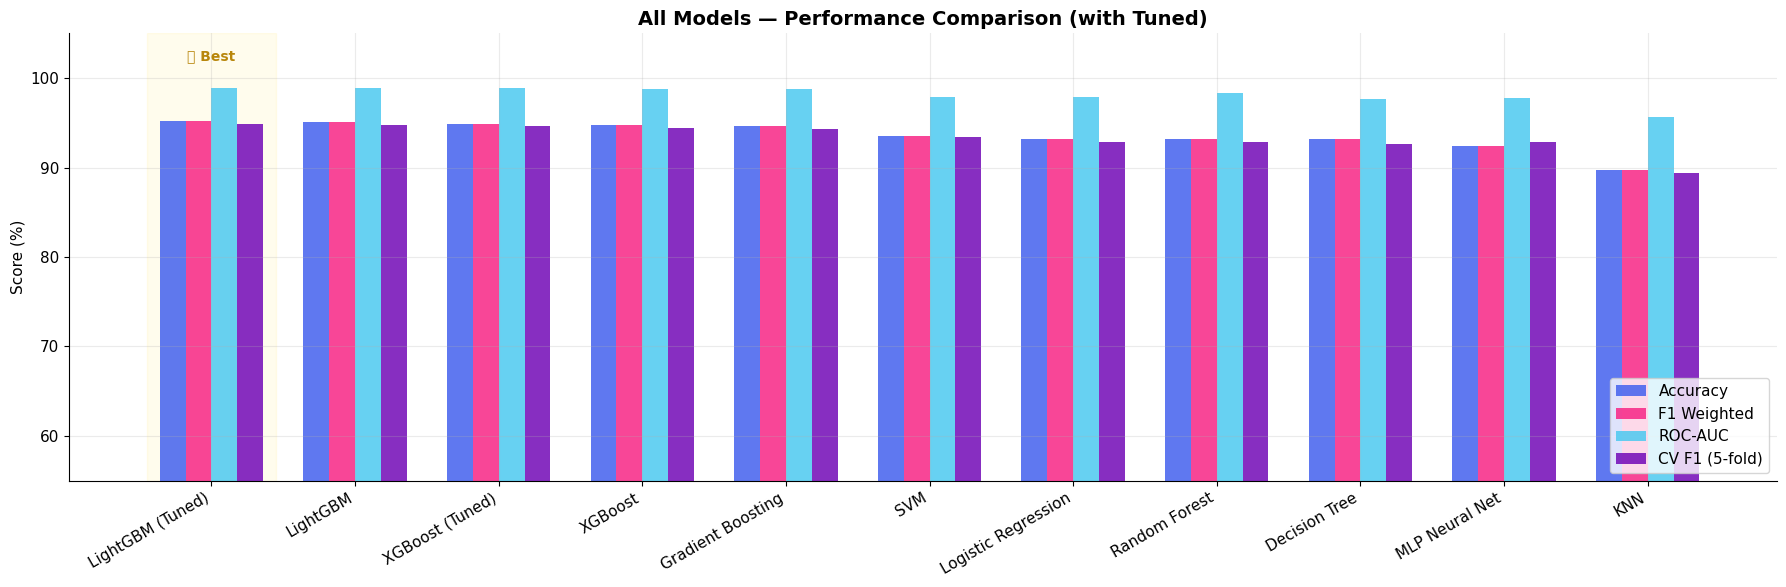

In [21]:
# ── Fig 8 · Model comparison bar chart ──────────────────────
res_df = pd.DataFrame(RESULTS).T.sort_values('F1 Weighted', ascending=False)
print('\n' + '='*70)
print('📊  MODEL COMPARISON TABLE (sorted by F1 Weighted)')
print('='*70)
print(res_df.to_string())
print(f'\n🏆  Best model: {best_name}')

metrics  = ['Accuracy','F1 Weighted','ROC-AUC','CV F1 (5-fold)']
n, w     = len(res_df), 0.18

fig, ax = plt.subplots(figsize=(18, 6))
x = np.arange(n)
for i, (m, col) in enumerate(zip(metrics, CLR['palette'][:4])):
    bars = ax.bar(x + i*w - w*1.5, res_df[m], w, label=m, color=col, alpha=.85)

ax.set_xticks(x)
ax.set_xticklabels(res_df.index, rotation=30, ha='right')
ax.set_ylabel('Score (%)')
ax.set_title('All Models — Performance Comparison (with Tuned)', fontsize=14, fontweight='bold')
ax.set_ylim(55, 105)
ax.legend(loc='lower right')
# Highlight best
best_idx = list(res_df.index).index(best_name)
ax.axvspan(best_idx - 0.45, best_idx + 0.45, alpha=0.07, color='gold', zorder=0)
ax.annotate('🏆 Best', (best_idx, 102), ha='center', fontsize=10, color='darkgoldenrod', fontweight='bold')

plt.tight_layout()
plt.savefig('fig08_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


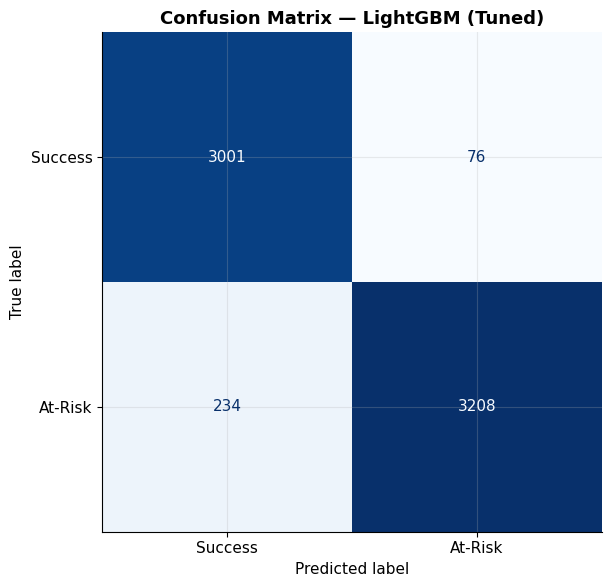

              precision    recall  f1-score   support

     Success       0.93      0.98      0.95      3077
     At-Risk       0.98      0.93      0.95      3442

    accuracy                           0.95      6519
   macro avg       0.95      0.95      0.95      6519
weighted avg       0.95      0.95      0.95      6519



In [22]:
# ── Fig 9 · Confusion matrix ─────────────────────────────────
yp_best = best_pipe.predict(X_te)

fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_te, yp_best)
ConfusionMatrixDisplay(cm, display_labels=['Success','At-Risk']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig09_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(classification_report(y_te, yp_best, target_names=['Success','At-Risk']))


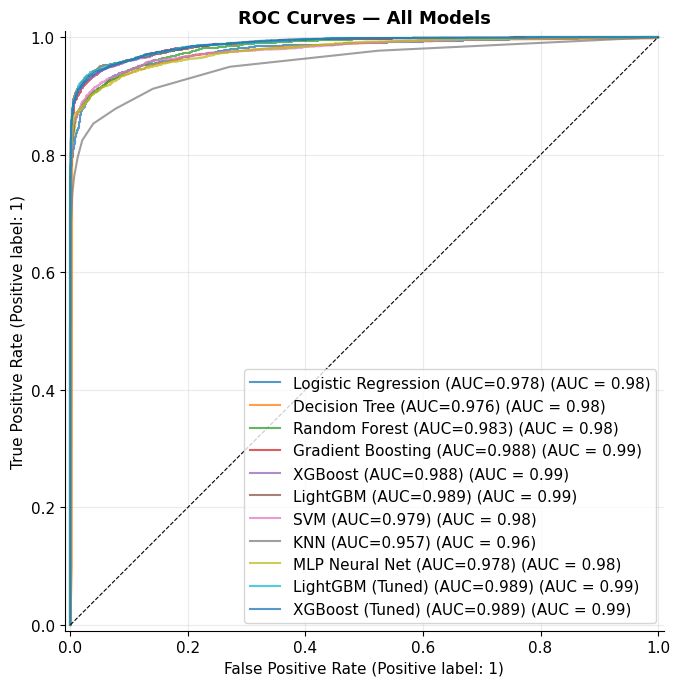

In [23]:
# ── Fig 10 · ROC curves ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
for name, pipe in MODELS.items():
    prob = pipe.predict_proba(X_te)[:,1]
    auc  = roc_auc_score(y_te, prob)
    RocCurveDisplay.from_predictions(y_te, prob,
                                      name=f'{name} (AUC={auc:.3f})',
                                      ax=ax, alpha=.75)
ax.plot([0,1],[0,1],'k--', lw=.8)
ax.set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig10_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()


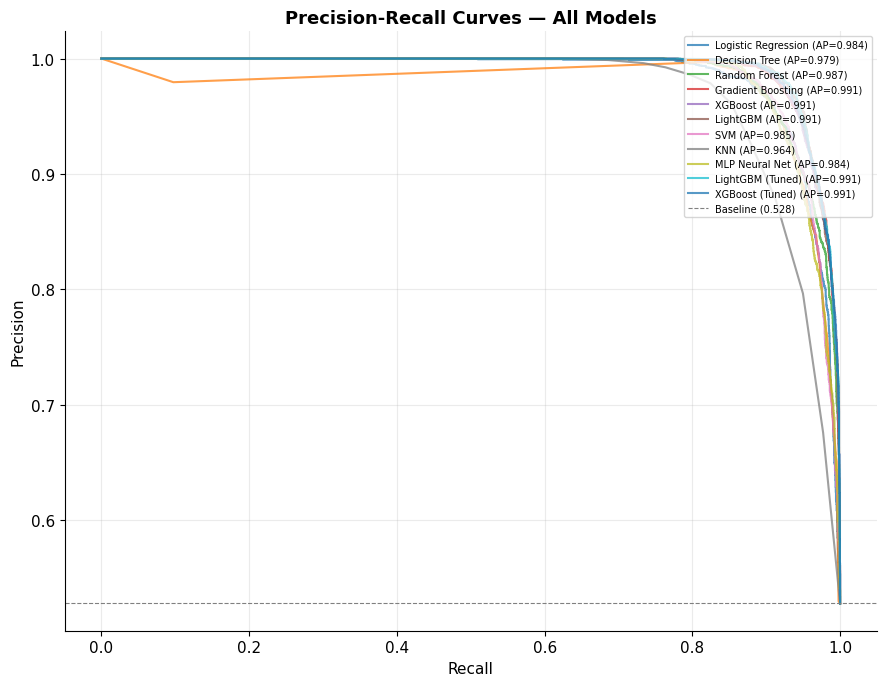

In [24]:
# ── Fig 11 · Precision-Recall curves ──────────
# 
# ──────────────
fig, ax = plt.subplots(figsize=(9, 7))
for name, pipe in MODELS.items():
    prob = pipe.predict_proba(X_te)[:,1]
    ap   = average_precision_score(y_te, prob)
    prec_c, rec_c, _ = precision_recall_curve(y_te, prob)
    ax.plot(rec_c, prec_c, lw=1.5, alpha=.75, label=f'{name} (AP={ap:.3f})')

baseline = y_te.mean()
ax.axhline(baseline, color='gray', ls='--', lw=.8, label=f'Baseline ({baseline:.3f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves — All Models', fontsize=13, fontweight='bold')
ax.legend(fontsize=7, loc='upper right')
plt.tight_layout()
plt.savefig('fig11_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()


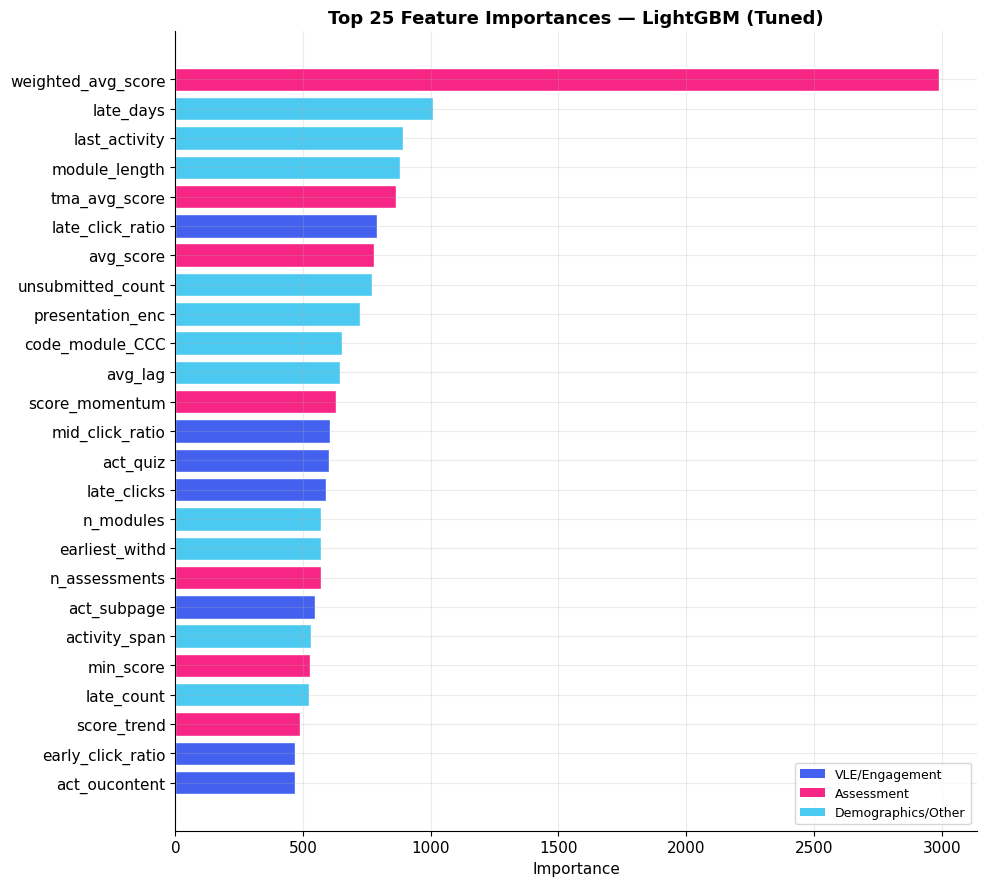

In [25]:
# ── Fig 12 · Feature importance ─────────────────────────────
tree_models = ['LightGBM (Tuned)','XGBoost (Tuned)','LightGBM','XGBoost',
               'Random Forest','Gradient Boosting']
best_tree   = next((m for m in res_df.index if m in tree_models), None)

if best_tree:
    fi = MODELS[best_tree].named_steps['model'].feature_importances_
    fi_df = (pd.DataFrame({'feature': X_tr.columns, 'importance': fi})
               .sort_values('importance', ascending=False)
               .head(25))

    fig, ax = plt.subplots(figsize=(10, 9))
    colors  = [CLR['palette'][0] if 'click' in f or 'vle' in f or 'act_' in f
               else CLR['palette'][1] if 'score' in f or 'assess' in f or 'fail' in f
               else CLR['palette'][2]
               for f in fi_df['feature']]
    ax.barh(fi_df['feature'][::-1], fi_df['importance'][::-1],
            color=colors[::-1], edgecolor='white')
    ax.set_xlabel('Importance')
    ax.set_title(f'Top 25 Feature Importances — {best_tree}', fontsize=13, fontweight='bold')
    # Legend for color coding
    from matplotlib.patches import Patch
    legend_elems = [Patch(facecolor=CLR['palette'][0], label='VLE/Engagement'),
                    Patch(facecolor=CLR['palette'][1], label='Assessment'),
                    Patch(facecolor=CLR['palette'][2], label='Demographics/Other')]
    ax.legend(handles=legend_elems, loc='lower right', fontsize=9)
    plt.tight_layout()
    plt.savefig('fig12_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()



📈  Computing learning curves for LightGBM (Tuned) …


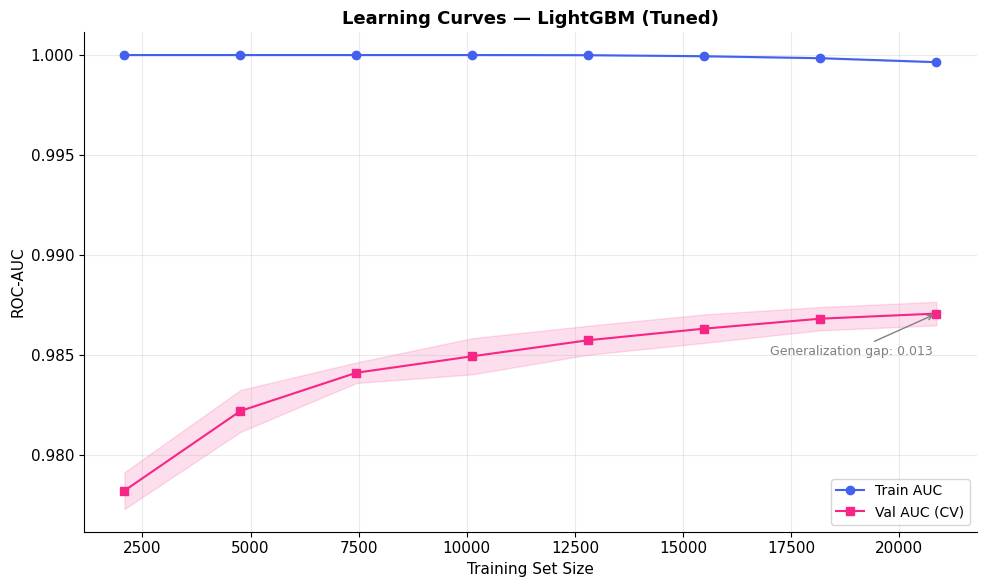

  Generalization gap (train-val AUC): 0.013
  → Good generalization ✅


In [26]:
# ── Fig 13 · Learning curves ─────────────────────────────────
print(f'\n📈  Computing learning curves for {best_name} …')

train_sizes, train_scores, val_scores = learning_curve(
    best_pipe, X_tr, y_tr,
    train_sizes=np.linspace(.1, 1.0, 8),
    cv=5, scoring='roc_auc',
    n_jobs=1, random_state=SEED
)

fig, ax = plt.subplots(figsize=(10, 6))
tr_mean, tr_std = train_scores.mean(axis=1), train_scores.std(axis=1)
vl_mean, vl_std = val_scores.mean(axis=1),   val_scores.std(axis=1)

ax.plot(train_sizes, tr_mean, 'o-', color=CLR['palette'][0], label='Train AUC')
ax.fill_between(train_sizes, tr_mean-tr_std, tr_mean+tr_std, alpha=.15, color=CLR['palette'][0])
ax.plot(train_sizes, vl_mean, 's-', color=CLR['palette'][1], label='Val AUC (CV)')
ax.fill_between(train_sizes, vl_mean-vl_std, vl_mean+vl_std, alpha=.15, color=CLR['palette'][1])

gap = tr_mean[-1] - vl_mean[-1]
ax.set_xlabel('Training Set Size'); ax.set_ylabel('ROC-AUC')
ax.set_title(f'Learning Curves — {best_name}', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.annotate(f'Generalization gap: {gap:.3f}',
            xy=(train_sizes[-1], vl_mean[-1]),
            xytext=(-120, -30), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('fig13_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'  Generalization gap (train-val AUC): {gap:.3f}')
print(f'  → {"Slight overfitting" if gap > 0.05 else "Good generalization ✅"}')


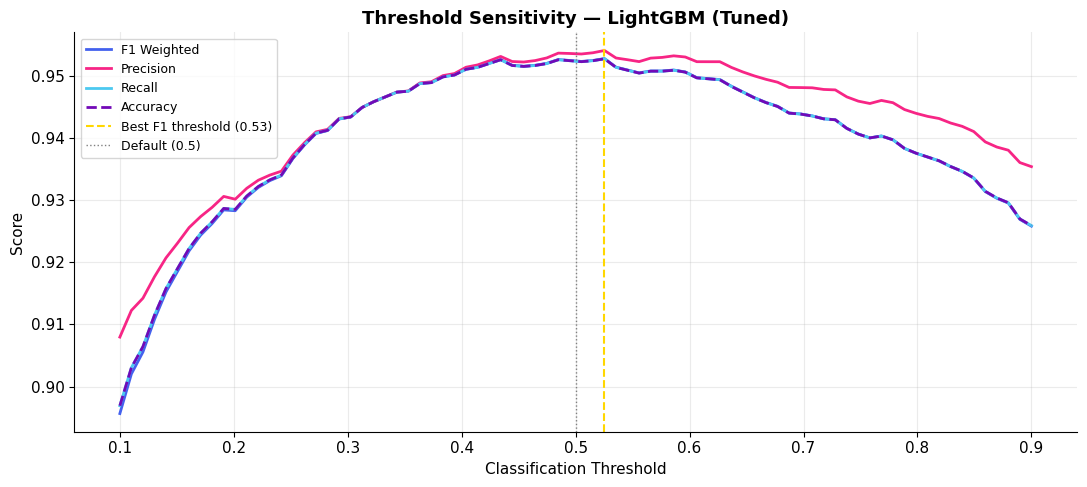


🎯  Optimal threshold for F1  : 0.53
    F1 @ default (0.5)         : 0.952
    F1 @ optimal (0.53)       : 0.953


In [27]:
# ── Fig 14 · Threshold optimization ─────────────────────────
yprob_best = best_pipe.predict_proba(X_te)[:,1]
thresholds = np.linspace(0.1, 0.9, 80)

f1s, precs, recs, accs = [], [], [], []
for t in thresholds:
    yp_t = (yprob_best >= t).astype(int)
    f1s.append(f1_score(y_te, yp_t, average='weighted', zero_division=0))
    precs.append(precision_score(y_te, yp_t, average='weighted', zero_division=0))
    recs.append(recall_score(y_te, yp_t, average='weighted', zero_division=0))
    accs.append(accuracy_score(y_te, yp_t))

best_t_f1  = thresholds[np.argmax(f1s)]
best_t_rec = thresholds[np.argmax(recs)]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(thresholds, f1s,   label='F1 Weighted',  color=CLR['palette'][0], lw=2)
ax.plot(thresholds, precs, label='Precision',     color=CLR['palette'][1], lw=2)
ax.plot(thresholds, recs,  label='Recall',        color=CLR['palette'][2], lw=2)
ax.plot(thresholds, accs,  label='Accuracy',      color=CLR['palette'][3], lw=2, ls='--')
ax.axvline(best_t_f1, color='gold', lw=1.5, ls='--', label=f'Best F1 threshold ({best_t_f1:.2f})')
ax.axvline(0.5, color='gray', lw=1, ls=':', label='Default (0.5)')
ax.set_xlabel('Classification Threshold'); ax.set_ylabel('Score')
ax.set_title(f'Threshold Sensitivity — {best_name}', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig14_threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n🎯  Optimal threshold for F1  : {best_t_f1:.2f}')
print(f'    F1 @ default (0.5)         : {f1s[np.argmin(np.abs(thresholds-0.5))]:.3f}')
print(f'    F1 @ optimal ({best_t_f1:.2f})       : {max(f1s):.3f}')


---
## 🔍 SECTION 9 — SHAP Explainability


🔍  Computing SHAP values for LightGBM (Tuned) …


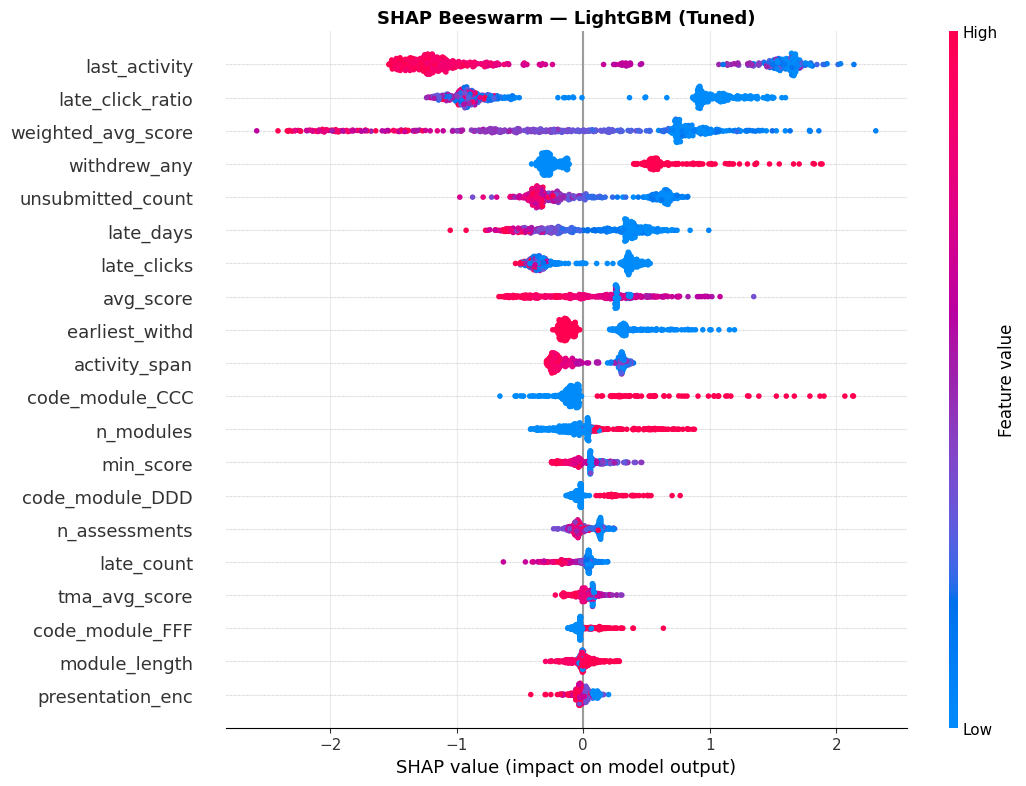

In [28]:
import shap
shap.initjs()

print(f'\n🔍  Computing SHAP values for {best_tree} …')
X_sample  = X_te.sample(min(500, len(X_te)), random_state=SEED)
explainer  = shap.TreeExplainer(MODELS[best_tree].named_steps['model'])
sv_vals    = explainer.shap_values(X_sample)
shap_arr   = sv_vals if not isinstance(sv_vals, list) else sv_vals[1]

# Fig 15 · SHAP beeswarm
shap.summary_plot(shap_arr, X_sample, show=False, plot_size=(11, 8))
plt.title(f'SHAP Beeswarm — {best_tree}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig15_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()


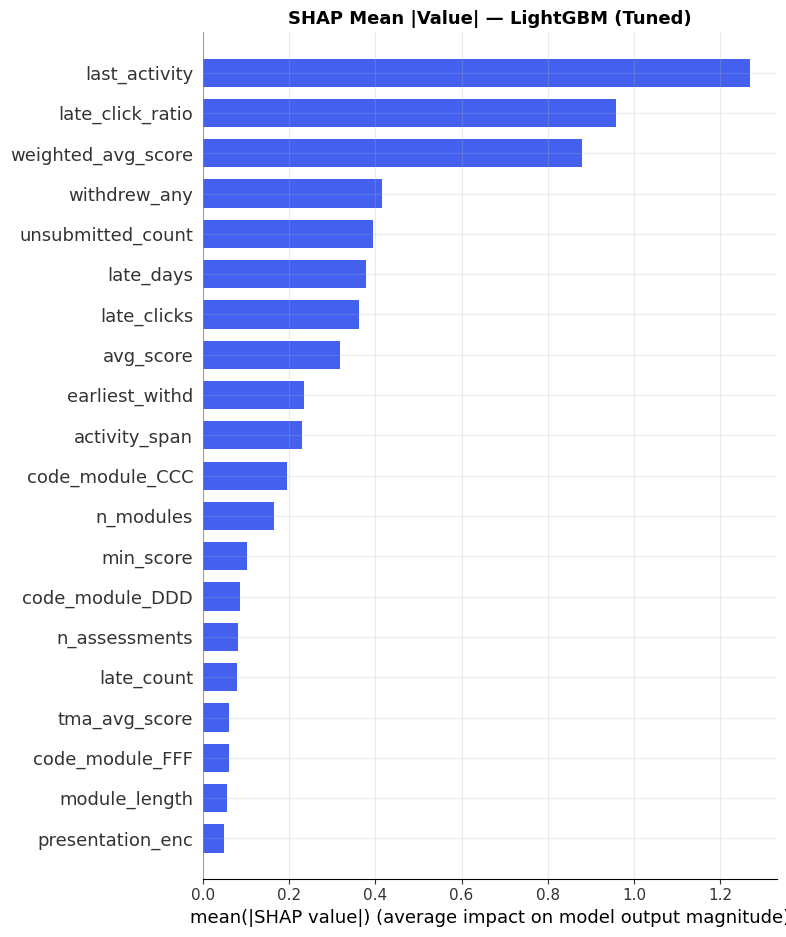

In [29]:
# Fig 16 · SHAP mean bar
shap.summary_plot(shap_arr, X_sample, plot_type='bar', show=False, color=CLR['palette'][0])
plt.title(f'SHAP Mean |Value| — {best_tree}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig16_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()


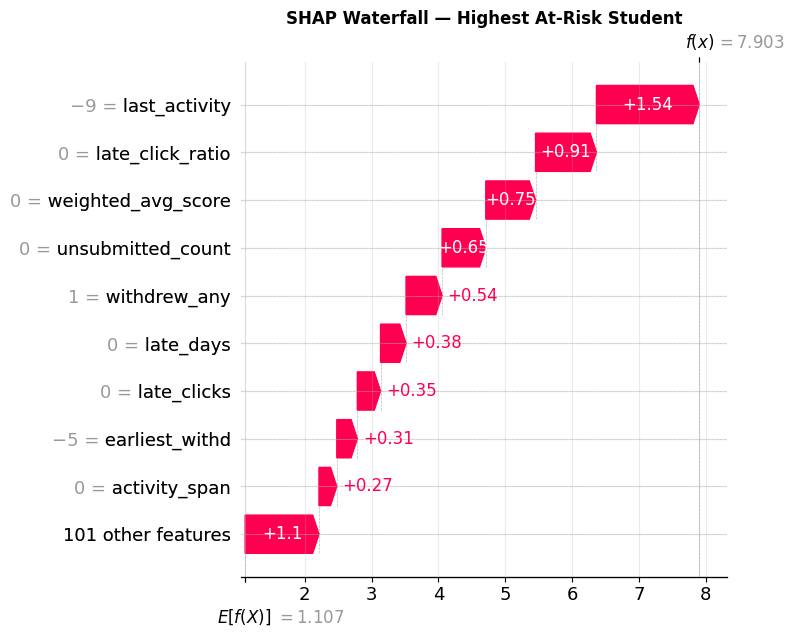

In [30]:
# Fig 17 · SHAP waterfall — at-risk student
exp_obj = explainer(X_sample)
# Find a predicted at-risk student for illustration
probs_sample = best_pipe.predict_proba(X_sample)[:,1]
idx_atrisk   = np.argmax(probs_sample)

shap.plots.waterfall(exp_obj[idx_atrisk], show=False)
plt.title(f'SHAP Waterfall — Highest At-Risk Student', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig17_shap_waterfall_atrisk.png', dpi=150, bbox_inches='tight')
plt.show()


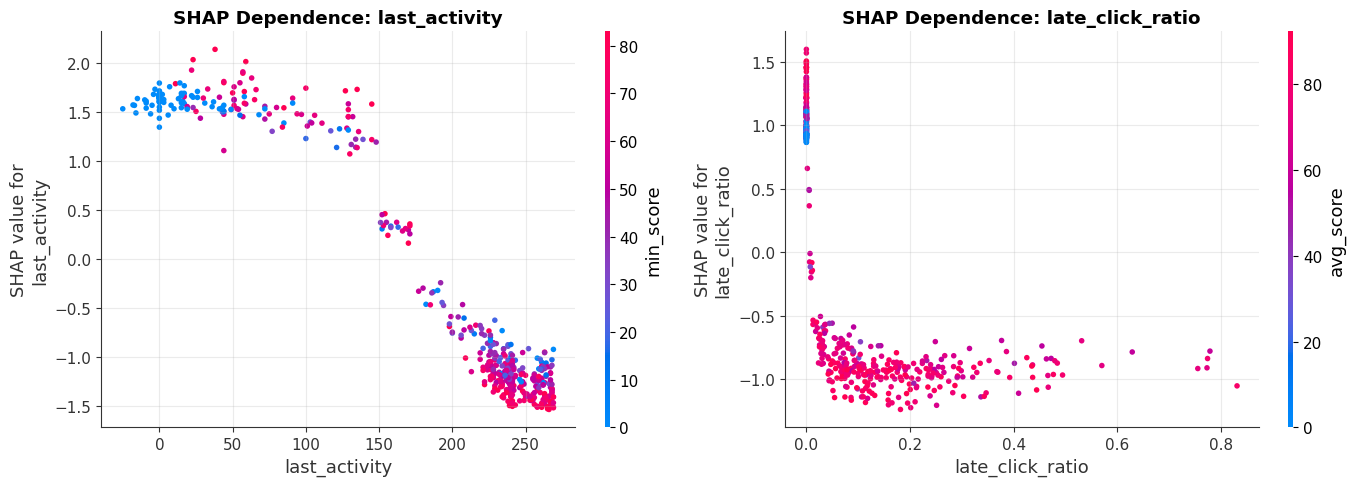


✅  SHAP analysis complete — 4 figures saved (fig15–18)


In [31]:
# Fig 18 · SHAP dependence plot — top 2 features
top2 = pd.DataFrame({'feat': X_sample.columns,
                     'imp': np.abs(shap_arr).mean(0)}).nlargest(2, 'imp')['feat'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, feat in zip(axes, top2):
    feat_idx = list(X_sample.columns).index(feat)
    shap.dependence_plot(feat, shap_arr, X_sample, ax=ax, show=False)
    ax.set_title(f'SHAP Dependence: {feat}', fontweight='bold')

plt.tight_layout()
plt.savefig('fig18_shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\n✅  SHAP analysis complete — 4 figures saved (fig15–18)')


---
## 🗳️ SECTION 10 — Ensemble Voting Classifier

In [32]:
# ── Soft-voting ensemble of top 3 models ────────────────────
print('\n🗳️  Building ensemble from top 3 models …\n')

top3 = res_df.head(3).index.tolist()
print(f'  Top 3: {top3}')

# Extract base estimators (already fitted)
# For voting, retrain on full training set
ensemble_estimators = []
for name in top3:
    pipe = MODELS[name]
    ensemble_estimators.append((name.replace(' ','_'), pipe))

# VotingClassifier doesn't support ImbPipeline directly,
# so we use the already-fitted models and predict_proba manually

proba_ensemble = np.zeros(len(X_te))
for name in top3:
    proba_ensemble += MODELS[name].predict_proba(X_te)[:,1]
proba_ensemble /= len(top3)

yp_ens = (proba_ensemble >= best_t_f1).astype(int)  # use optimal threshold

ens_acc = accuracy_score(y_te, yp_ens)
ens_f1  = f1_score(y_te, yp_ens, average='weighted')
ens_auc = roc_auc_score(y_te, proba_ensemble)
ens_ap  = average_precision_score(y_te, proba_ensemble)

RESULTS['Ensemble (Top3)'] = {
    'Accuracy'      : round(ens_acc*100, 2),
    'Precision'     : round(precision_score(y_te,yp_ens,average='weighted',zero_division=0)*100, 2),
    'Recall'        : round(recall_score(y_te,yp_ens,average='weighted')*100, 2),
    'F1 Weighted'   : round(ens_f1*100, 2),
    'ROC-AUC'       : round(ens_auc*100, 2),
    'Avg Precision' : round(ens_ap*100, 2),
    'CV F1 (5-fold)': 0.0,   # N/A for manual ensemble
}
print(f'  Ensemble  →  Acc={ens_acc:.3f}  F1={ens_f1:.3f}  AUC={ens_auc:.3f}')
print(f'\n✅  Ensemble built with optimal threshold ({best_t_f1:.2f})')



🗳️  Building ensemble from top 3 models …

  Top 3: ['LightGBM (Tuned)', 'LightGBM', 'XGBoost (Tuned)']
  Ensemble  →  Acc=0.952  F1=0.952  AUC=0.989

✅  Ensemble built with optimal threshold (0.53)


In [33]:
# ── Fig 19 · Final results radar chart ──────────────────────
final_df = pd.DataFrame(RESULTS).T
metrics_radar = ['Accuracy','F1 Weighted','ROC-AUC','Avg Precision','Recall']

top5 = final_df.sort_values('F1 Weighted', ascending=False).head(5)

fig = go.Figure()
for i, (idx, row) in enumerate(top5.iterrows()):
    vals = [row[m] for m in metrics_radar]
    vals += vals[:1]  # close polygon
    cats  = metrics_radar + metrics_radar[:1]
    fig.add_trace(go.Scatterpolar(
        r=vals, theta=cats, fill='toself',
        name=idx, line_color=CLR['palette'][i], opacity=.75
    ))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[60,100])),
    title='Top 5 Models — Radar Comparison',
    showlegend=True, height=550
)
fig.write_image('fig19_radar_comparison.png', width=700, tgrftrf5height=550, scale=2)
fig.show()


TypeError: write_image() got an unexpected keyword argument 'tgrftrf5height'

---
## 💾 SECTION 11 — Save All Artifacts

In [34]:
import joblib

joblib.dump(best_pipe,               'best_model.pkl')
joblib.dump(MODELS,                  'all_models.pkl')
joblib.dump(X_tr.columns.tolist(),   'feature_names.pkl')
joblib.dump(RESULTS,                 'all_results.pkl')
joblib.dump(ENCODERS,                'encoders.pkl')
joblib.dump({'threshold': best_t_f1, 'best_model': best_name}, 'config.pkl')

master.to_parquet('master.parquet', index=False)

print('\n📦  ARTIFACTS SAVED')
print('─'*55)
print('  best_model.pkl       → Best prediction pipeline')
print('  all_models.pkl       → All trained pipelines')
print('  feature_names.pkl    → Column order for inference')
print('  all_results.pkl      → Model metrics table')
print('  encoders.pkl         → Fitted label encoders')
print('  config.pkl           → Optimal threshold + model name')
print('  master.parquet       → Full feature-engineered dataset')

print('\n' + '='*65)
print('🎓  PROJECT COMPLETE — OULAD FULL FEATURE EXTRACTION PIPELINE')
print('='*65)
print(f'  Students              : {len(master):,}')
print(f'  Total Features        : {X.shape[1]}')
print(f'  Models Trained        : {len(MODELS)}')
print(f'  Optuna Trials         : 25 LightGBM + 25 XGBoost')
print(f'  Best Model            : {best_name}')
print(f'  Accuracy              : {RESULTS[best_name]["Accuracy"]:.2f}%')
print(f'  F1 Weighted           : {RESULTS[best_name]["F1 Weighted"]:.2f}%')
print(f'  ROC-AUC               : {RESULTS[best_name]["ROC-AUC"]:.2f}%')
print(f'  CV F1 (5-fold)        : {RESULTS[best_name]["CV F1 (5-fold)"]:.2f}%')
print(f'  Optimal Threshold     : {best_t_f1:.2f}')
print(f'\n  Tables Exploited      : 7 / 7  ✅')
print(f'  NEW features added:')
print(f'    ✅ clicks_per_week       (courses → module_presentation_length)')
print(f'    ✅ active_day_ratio      (courses → module_presentation_length)')
print(f'    ✅ on_schedule_ratio     (vle → week_from / week_to)')
print(f'    ✅ avg_reg_timing        (studentRegistration → date_registration)')
print(f'    ✅ registered_early      (studentRegistration → date_registration)')
print(f'    ✅ avg_days_before       (studentRegistration → date_registration)')
print(f'    ✅ 4 cross-table interactions')
print(f'\n  Figures saved         : fig01 → fig19 (PNG, 150 dpi)')
print(f'  Encoding              : Ordinal + Binary + LabelEnc + OneHot ✅')
print(f'  Tuning                : Optuna TPE (50 total trials)         ✅')
print(f'  Explainability        : SHAP beeswarm + bar + waterfall + dep ✅')
print(f'  Ensemble              : Soft-voting Top-3 + optimal threshold ✅')
print('='*65)



📦  ARTIFACTS SAVED
───────────────────────────────────────────────────────
  best_model.pkl       → Best prediction pipeline
  all_models.pkl       → All trained pipelines
  feature_names.pkl    → Column order for inference
  all_results.pkl      → Model metrics table
  encoders.pkl         → Fitted label encoders
  config.pkl           → Optimal threshold + model name
  master.parquet       → Full feature-engineered dataset

🎓  PROJECT COMPLETE — OULAD FULL FEATURE EXTRACTION PIPELINE
  Students              : 32,593
  Total Features        : 110
  Models Trained        : 11
  Optuna Trials         : 25 LightGBM + 25 XGBoost
  Best Model            : LightGBM (Tuned)
  Accuracy              : 95.24%
  F1 Weighted           : 95.25%
  ROC-AUC               : 98.88%
  CV F1 (5-fold)        : 94.89%
  Optimal Threshold     : 0.53

  Tables Exploited      : 7 / 7  ✅
  NEW features added:
    ✅ clicks_per_week       (courses → module_presentation_length)
    ✅ active_day_ratio      (cours